# Tessera propAMM: how retail gets worse fills on Base

- In this notebook, we analyse execution quality on [Tessera](https://defillama.com/protocol/tessera-v), the Wintermute proprietary AMM (propAMM) that has become one of the largest trading venues on Base
- PropAMMs post quotes onchain from an off-chain pricing engine and are routed to by aggregators (OKX, KyberSwap, 1inch, 0x, Paraswap, Binance Wallet…) because their quoted prices beat AMM pools
- The [0x "PropAMM Shenanigans" post](https://0x.org/post/propamm-shenanigans) documented that the quoted price does not survive until settlement: the operator refreshes a tight quote in the last Flashblock of block N, aggregators route on it, then reprices worse in the first Flashblock of block N+1 where user transactions settle, and the user's slippage tolerance silently absorbs the difference
- We measure this over ten months of onchain history and answer three questions
  1. **Is the quote honest?** Does the price an aggregator routed on survive until the fill?
  2. **Who pays?** Retail vs bots, by aggregator and by front-end
  3. **How much?** In basis points against Tessera's own quote and against a fair reference price from the deepest Uniswap V3 / Aerodrome pool, and in dollars
- Finally we look for the mechanism: *why* retail fills are worse than bot fills on the same venue in the same blocks

## Usage

This is an open source notebook based on open data
- You can edit and remix this notebook yourself

To do your own data research:

- Read general instructions [how to run the tutorials](./)
- Run `scripts/base/scan-tessera-propamm.py` to collect Tessera trades, keeper price updates, transaction traces (aggregator identification, user slippage bounds) and historical quotes into a DuckDB file
- Run `scripts/base/scan-tessera-benchmark-prices.py` to add reference pool prices for a fair-price comparison
- The default database location is `~/.tradingstrategy/tessera/tessera-base.duckdb`; override with `TESSERA_DUCKDB_PATH`

Terminology used below:

- **Quote**: Tessera's own `tesseraSwapViewAmounts()` output for the trade size at the end of the previous block — the best onchain approximation of what the aggregator routed on
- **Fill**: the amounts in the `TesseraTrade` event
- **Quote-to-fill bps**: `(quoted_out − filled_out) / quoted_out × 10 000`; positive means the user got less than quoted
- **Fair price**: the marginal (mid) price of the deepest concentrated-liquidity pool for the pair at the end of the previous block
- **Retail**: trades routed through a labelled aggregator router; **bot**: trades from known arbitrage contracts or EIP-7702 self-calls; **unlabelled**: routers we could not identify
- **In-block position**: `cumulative_gas_used / block_gas_used` of the transaction, 0 = top of block, 1 = bottom; Base blocks are built from ten 200 ms Flashblocks in order, so this is the proxy for the Flashblock index

## Setup

- Set up notebook rendering output mode
- Use static image charts so this notebook is readable on Github / ReadTheDocs
- Colours are assigned by role and kept fixed across every chart: retail is blue, bots are orange, unlabelled flow is grey, keeper price updates are aqua

In [1]:
import os
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.offline import init_notebook_mode
from plotly.subplots import make_subplots

from eth_defi.research.notebook import set_large_plotly_chart_font

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None
pd.options.display.max_rows = 60

image_format = "png"
width = 1400
height = 700

init_notebook_mode()
pio.renderers.default = image_format
current_renderer = pio.renderers[image_format]
current_renderer.width = width
current_renderer.height = height

set_large_plotly_chart_font(title_font_size=26, font_size=18, legend_font_size=18, axis_title_font_size=20, line_width=2)

# Fixed role colours, never cycled
COLOURS = {
    "retail": "#2a78d6",
    "bot": "#eb6834",
    "unlabelled": "#8a8a8a",
    "price update": "#1baf7a",
    "quote": "#4a3aa7",
    "fill": "#e34948",
}
FLOW_ORDER = ["retail", "bot", "unlabelled"]

# Fixed aggregator colour order (validated categorical palette, slots 1-8)
AGGREGATOR_COLOURS = {
    "okx": "#2a78d6",
    "kyberswap": "#eb6834",
    "0x": "#1baf7a",
    "1inch": "#eda100",
    "paraswap": "#e87ba4",
    "binance-wallet": "#008300",
    "lifi": "#4a3aa7",
    "aggregator-2f68": "#e34948",
}


def style(fig: go.Figure, title: str, xaxis: str, yaxis: str, legend: bool = True) -> go.Figure:
    """Apply the shared chart style: one y axis, recessive grid, legend only when needed."""
    fig.update_layout(
        title=title,
        xaxis_title=xaxis,
        yaxis_title=yaxis,
        template="plotly_white",
        showlegend=legend,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
        margin=dict(l=70, r=30, t=110, b=70),
        bargap=0.15,
    )
    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(gridcolor="#e6e6e3", zeroline=False)
    return fig

## Open the dataset

- Connect to the DuckDB file produced by the two scanner scripts, read-only
- The raw tables cover the full Tessera history on Base; the enrichment tables (traces, quotes, benchmarks) cover the analysis window from block 50,000,000 (roughly the last month)
- Show what we have

In [2]:
duckdb_path = Path(os.environ.get("TESSERA_DUCKDB_PATH", "~/.tradingstrategy/tessera/tessera-base.duckdb")).expanduser()
assert duckdb_path.exists(), f"Run scripts/base/scan-tessera-propamm.py first, {duckdb_path} missing"
con = duckdb.connect(str(duckdb_path), read_only=True)
con.execute("SET enable_progress_bar = false")

WINDOW_START_BLOCK = int(os.environ.get("TESSERA_WINDOW_START_BLOCK", "50000000"))
USDC = "0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913"
WETH = "0x4200000000000000000000000000000000000006"

tables = ["blocks", "trades", "price_updates", "trade_calls", "trade_orders", "quotes", "benchmark_swaps", "trade_benchmarks"]
overview = pd.DataFrame(
    [(t, con.execute(f"SELECT count(*) FROM {t}").fetchone()[0]) for t in tables],
    columns=["Table", "Rows"],
)
history = con.execute("SELECT min(timestamp), max(timestamp), min(block_number), max(block_number) FROM trades").fetchone()
window = con.execute("SELECT min(timestamp), max(timestamp) FROM trades WHERE block_number >= ?", [WINDOW_START_BLOCK]).fetchone()
print(f"Full history: {history[0]:%Y-%m-%d} – {history[1]:%Y-%m-%d} (blocks {history[2]:,} – {history[3]:,})")
print(f"Analysis window: {window[0]:%Y-%m-%d} – {window[1]:%Y-%m-%d} (block {WINDOW_START_BLOCK:,} onwards)")
display(overview.style.format({"Rows": "{:,}"}))

Full history: 2025-10-30 – 2026-09-16 (blocks 37,519,381 – 51,367,230)
Analysis window: 2026-08-15 – 2026-09-16 (block 50,000,000 onwards)


,Table,Rows
0,blocks,"12,974,168"
1,trades,"8,365,599"
2,price_updates,"56,485,825"
3,trade_calls,"524,765"
4,trade_orders,"524,765"
5,quotes,"1,867,800"
6,benchmark_swaps,"2,457,824"
7,trade_benchmarks,"456,099"


## Load trades in the analysis window

- Join the per-trade analysis view with the fair-price benchmark view
- Classify flow: `retail` is anything routed through a labelled aggregator router, `bot` is a known arbitrage contract or an EIP-7702 self-call, `unlabelled` is a router we could not identify
- Compute the USD notional from the USDC leg of the trade, and the dollar value of the quote-to-fill gap

In [3]:
df = con.execute("""
    SELECT
        a.block_number, a.timestamp, a.tx_hash, a.log_index, a.tx_index,
        a.token_in, a.token_out, a.symbol_in, a.symbol_out,
        a.amount_in_decimal, a.amount_out_decimal,
        a.aggregator, a.frontend, a.wallet_kind, a.client_data, a.is_self_call, a.router,
        a.rel_gas_position, a.max_priority_fee_per_gas,
        a.quote_to_fill_bps, a.same_block_quote_to_fill_bps, a.size_impact_bps,
        a.user_slippage_bps, a.user_slippage_consumed_fraction, a.user_headroom_bps, a.user_route_headroom_bps,
        a.given_slippage_bps, a.order_matches_leg,
        b.fill_vs_benchmark_bps, b.quote_vs_benchmark_bps, b.benchmark_age_blocks, b.protocol AS benchmark_protocol, b.benchmark_fee_bps
    FROM trade_analysis a
    LEFT JOIN trade_vs_benchmark b ON b.tx_hash = a.tx_hash AND b.log_index = a.log_index
    WHERE a.venue = 'tessera' AND a.block_number >= ?
""", [WINDOW_START_BLOCK]).df()

df["pair"] = df["symbol_in"] + "/" + df["symbol_out"]
df["flow"] = np.select(
    [(df["aggregator"] == "bot") | df["is_self_call"].fillna(False), df["aggregator"].notna()],
    ["bot", "retail"],
    default="unlabelled",
)
df["notional_usd"] = np.where(df["token_in"] == USDC, df["amount_in_decimal"], np.where(df["token_out"] == USDC, df["amount_out_decimal"], np.nan))
df["extracted_usd"] = df["quote_to_fill_bps"] / 10_000 * df["notional_usd"]
df["hour"] = df["timestamp"].dt.floor("h")
df["day"] = df["timestamp"].dt.floor("D")

summary = df.groupby("flow").agg(
    trades=("tx_hash", "size"),
    notional_usd=("notional_usd", "sum"),
    median_quote_to_fill_bps=("quote_to_fill_bps", "median"),
    has_user_bound=("user_slippage_bps", lambda s: s.notna().mean()),
).reindex(FLOW_ORDER)
summary["share_of_trades"] = summary["trades"] / summary["trades"].sum()
display(summary.style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "median_quote_to_fill_bps": "{:.2f}", "has_user_bound": "{:.0%}", "share_of_trades": "{:.0%}"}))

,trades,notional_usd,median_quote_to_fill_bps,has_user_bound,share_of_trades
flow,,,,,
retail,"217,897","$154,246,129",5.12,14%,47%
bot,"49,788","$283,656,290",-0.26,2%,11%
unlabelled,"199,265","$463,581,424",0.05,0%,43%


## Dataset overview: pairs and volume

- Tessera volume is concentrated in a handful of pairs against USDC
- Retail and bot flow have very different pair preferences: bots concentrate on WETH/USDC and cbBTC/USDC where the reference price is tightest

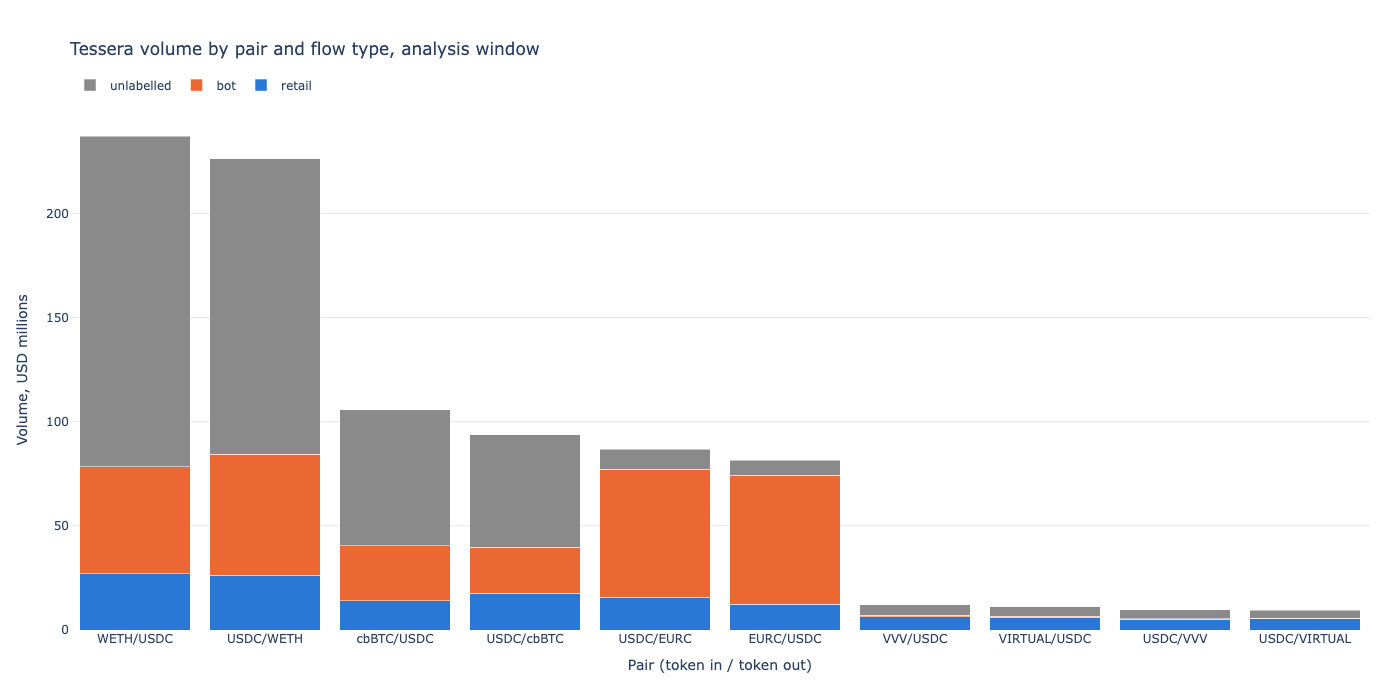

flow,bot,retail,unlabelled,total
pair,,,,
WETH/USDC,$51.4M,$27.1M,$158.7M,$237.1M
USDC/WETH,$58.0M,$26.3M,$142.0M,$226.3M
cbBTC/USDC,$26.5M,$14.0M,$65.3M,$105.7M
USDC/cbBTC,$22.1M,$17.6M,$54.0M,$93.7M
USDC/EURC,$61.4M,$15.7M,$9.5M,$86.7M
EURC/USDC,$62.1M,$12.3M,$7.0M,$81.4M
VVV/USDC,$0.6M,$6.4M,$5.1M,$12.1M
VIRTUAL/USDC,$0.4M,$6.2M,$4.6M,$11.2M
USDC/VVV,$0.2M,$5.1M,$4.4M,$9.7M


In [4]:
pairs = df.groupby(["pair", "flow"]).agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum")).reset_index()
pair_order = pairs.groupby("pair")["notional_usd"].sum().sort_values(ascending=False).index[:10]
pairs = pairs[pairs["pair"].isin(pair_order)]

fig = go.Figure()
for flow in FLOW_ORDER:
    sub = pairs[pairs["flow"] == flow].set_index("pair").reindex(pair_order)
    fig.add_bar(name=flow, x=list(pair_order), y=sub["notional_usd"] / 1e6, marker_color=COLOURS[flow])
fig.update_layout(barmode="stack")
style(fig, "Tessera volume by pair and flow type, analysis window", "Pair (token in / token out)", "Volume, USD millions").show()

table = df.pivot_table(index="pair", columns="flow", values="notional_usd", aggfunc="sum", fill_value=0).reindex(pair_order)
table["total"] = table.sum(axis=1)
display((table / 1e6).style.format("${:,.1f}M"))

# Question 1: is the quote honest?

## Where in the block does the keeper update prices?

- Tessera's pricing engine reads quotes from a store contract that the operator's keeper wallet writes to several times per block, with no events emitted
- If updates were driven by market data they would be spread evenly through the block
- Instead they cluster at the very top and the very bottom of the block: the 0x post's "quote in the last Flashblock, reprice in the first Flashblock" signature, here over the whole analysis window

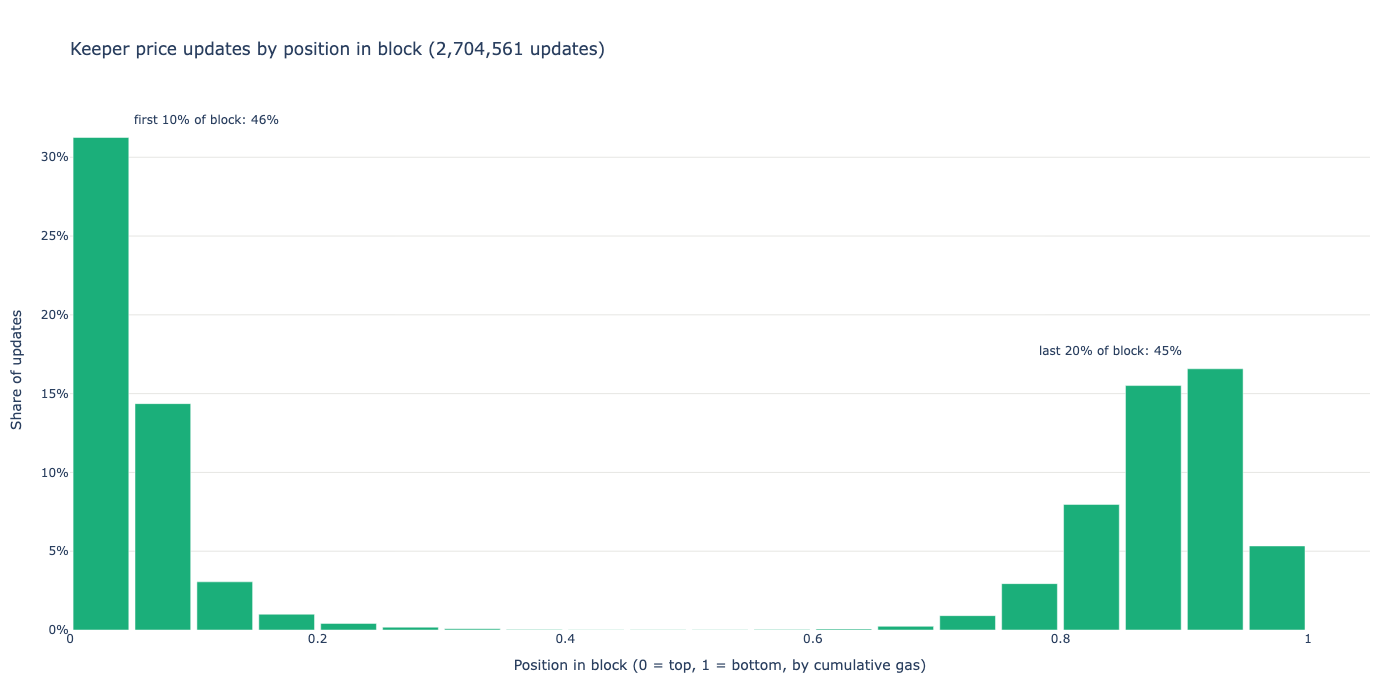

In [5]:
updates = con.execute("""
    SELECT floor(rel_gas_position * 20) / 20 AS position_bin, count(*) AS n
    FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND rel_gas_position IS NOT NULL
    GROUP BY 1 ORDER BY 1
""", [WINDOW_START_BLOCK]).df()
updates["share"] = updates["n"] / updates["n"].sum()

fig = go.Figure(go.Bar(x=updates["position_bin"] + 0.025, y=updates["share"], width=0.045, marker_color=COLOURS["price update"], name="price updates"))
top = updates.loc[updates["position_bin"] < 0.1, "share"].sum()
bottom = updates.loc[updates["position_bin"] >= 0.8, "share"].sum()
fig.add_annotation(x=0.05, y=updates["share"].max(), text=f"first 10% of block: {top:.0%}", showarrow=False, yshift=18, xanchor="left")
fig.add_annotation(x=0.9, y=updates.loc[updates["position_bin"] >= 0.8, "share"].max(), text=f"last 20% of block: {bottom:.0%}", showarrow=False, yshift=18, xanchor="right")
style(fig, f"Keeper price updates by position in block ({updates['n'].sum():,} updates)", "Position in block (0 = top, 1 = bottom, by cumulative gas)", "Share of updates", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()

## Quote survival: how much worse is the fill than the quote?

- For every trade we recomputed Tessera's own quote for the exact trade size at the end of the previous block, the moment an aggregator would have snapshotted it
- Positive quote-to-fill bps means the user received less than that quote
- Retail flow pays a consistent few basis points; bots fill at or better than the quote
- The retail curve has steps at exactly 0, 1, 2 and 4 bps: the degradation is quantised in whole basis points, a discrete pricing parameter rather than continuous market noise

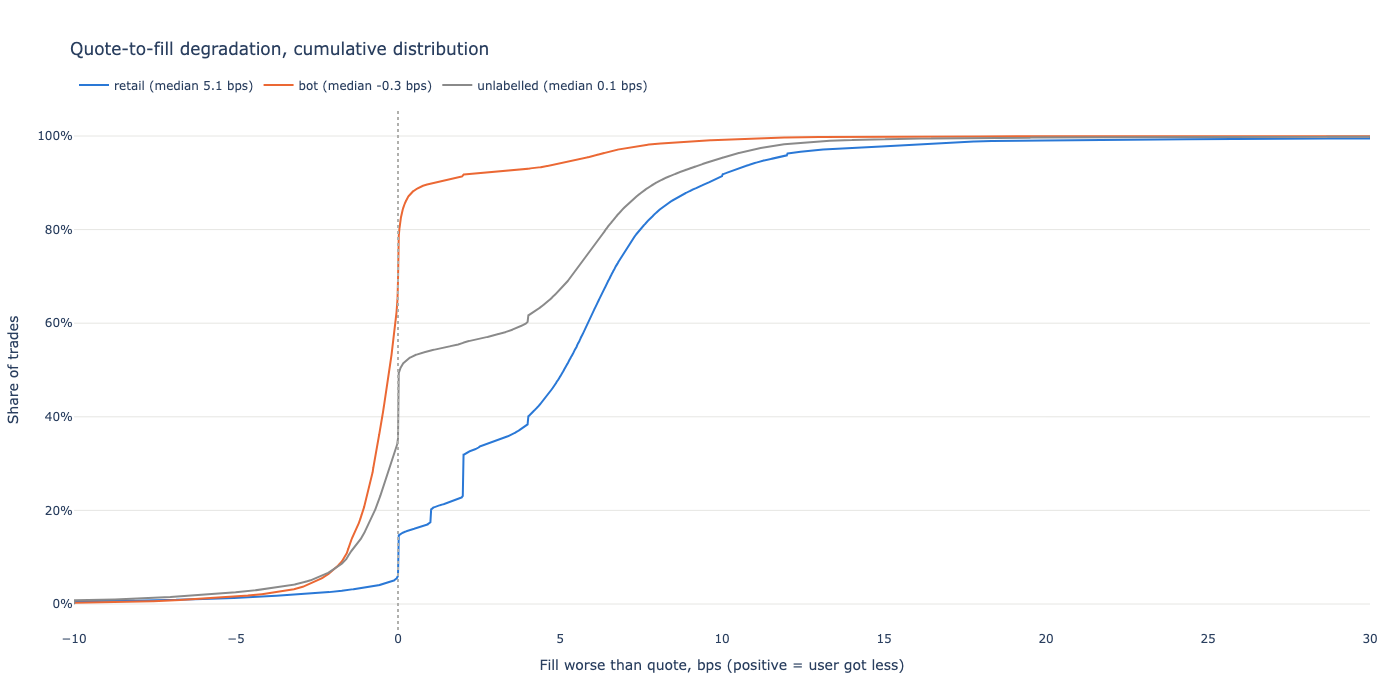

,count,mean,10%,50%,90%,99%
flow,,,,,,
retail,"217,887.00",5.05,0.00,5.12,9.56,19.15
bot,"49,704.00",-0.10,-1.64,-0.26,1.06,9.39
unlabelled,"199,086.00",2.50,-1.56,0.05,7.96,13.32


In [6]:
fig = go.Figure()
for flow in FLOW_ORDER:
    s = df.loc[df["flow"] == flow, "quote_to_fill_bps"].dropna().clip(-10, 30).sort_values()
    fig.add_scatter(x=s.values, y=np.linspace(0, 1, len(s)), mode="lines", name=f"{flow} (median {s.median():.1f} bps)", line=dict(color=COLOURS[flow], width=2))
fig.add_vline(x=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Quote-to-fill degradation, cumulative distribution", "Fill worse than quote, bps (positive = user got less)", "Share of trades")
fig.update_yaxes(tickformat=".0%")
fig.show()

q = df.groupby("flow")["quote_to_fill_bps"].describe(percentiles=[0.1, 0.5, 0.9, 0.99]).reindex(FLOW_ORDER)[["count", "mean", "10%", "50%", "90%", "99%"]]
display(q.style.format("{:,.2f}"))

## Quote survival by pair

- The degradation is not a property of one illiquid token: it is present on WETH/USDC and cbBTC/USDC, the deepest markets on Base
- The bottom of the distribution (p10) sits around one basis point on the majors — a spread-like floor — while the median is five to six

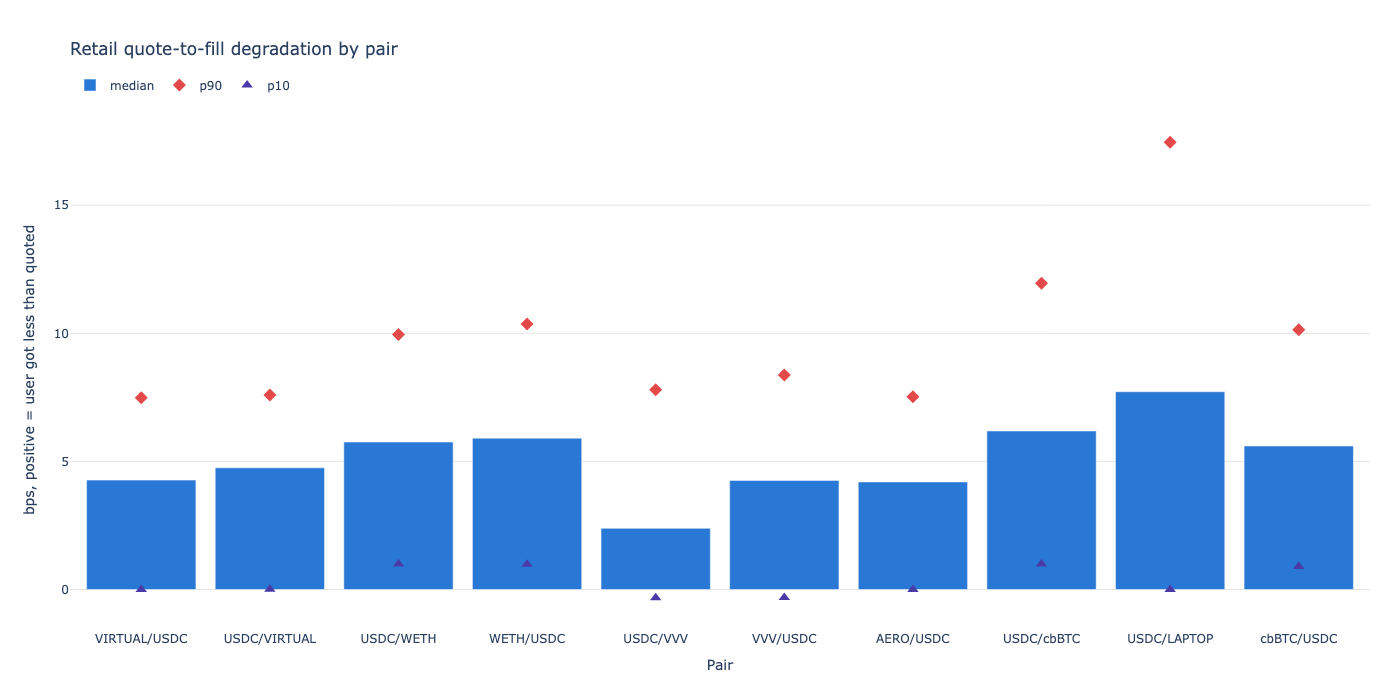

,n,p10,p50,p90,mean
pair,,,,,
VIRTUAL/USDC,"31,847",0.00,4.27,7.49,4.18
USDC/VIRTUAL,"29,862",0.01,4.75,7.59,4.13
USDC/WETH,"28,220",1.00,5.76,9.95,5.53
WETH/USDC,"26,537",0.99,5.91,10.36,6.14
USDC/VVV,"12,839",-0.32,2.39,7.80,3.37
VVV/USDC,"12,708",-0.32,4.26,8.37,4.03
AERO/USDC,"12,382",0.00,4.20,7.52,4.07
USDC/cbBTC,"11,023",1.00,6.19,11.96,9.50
USDC/LAPTOP,"10,601",0.00,7.72,17.46,8.31


In [7]:
retail = df[df["flow"] == "retail"]
by_pair = retail.groupby("pair")["quote_to_fill_bps"].agg(n="size", p10=lambda s: s.quantile(0.1), p50="median", p90=lambda s: s.quantile(0.9), mean="mean")
by_pair = by_pair[by_pair["n"] >= 1000].sort_values("n", ascending=False).head(10)

fig = go.Figure()
fig.add_bar(x=by_pair.index, y=by_pair["p50"], name="median", marker_color=COLOURS["retail"])
fig.add_scatter(x=by_pair.index, y=by_pair["p90"], mode="markers", name="p90", marker=dict(color=COLOURS["fill"], size=10, symbol="diamond"))
fig.add_scatter(x=by_pair.index, y=by_pair["p10"], mode="markers", name="p10", marker=dict(color=COLOURS["quote"], size=10, symbol="triangle-up"))
style(fig, "Retail quote-to-fill degradation by pair", "Pair", "bps, positive = user got less than quoted").show()
display(by_pair.style.format({"n": "{:,}", "p10": "{:.2f}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}"}))

## Price movement inside a block vs between blocks

- In a normal market the price moves more between blocks (two seconds apart) than inside a block (200 ms Flashblocks)
- 0x reported the inverse for propAMMs: five to seven times more movement within the block than across blocks
- We reproduce this with Tessera's own probe quote for WETH→USDC: the quote at the end of the previous block vs the end of the trade's block (intra-block) against the change between consecutive block ends (inter-block)

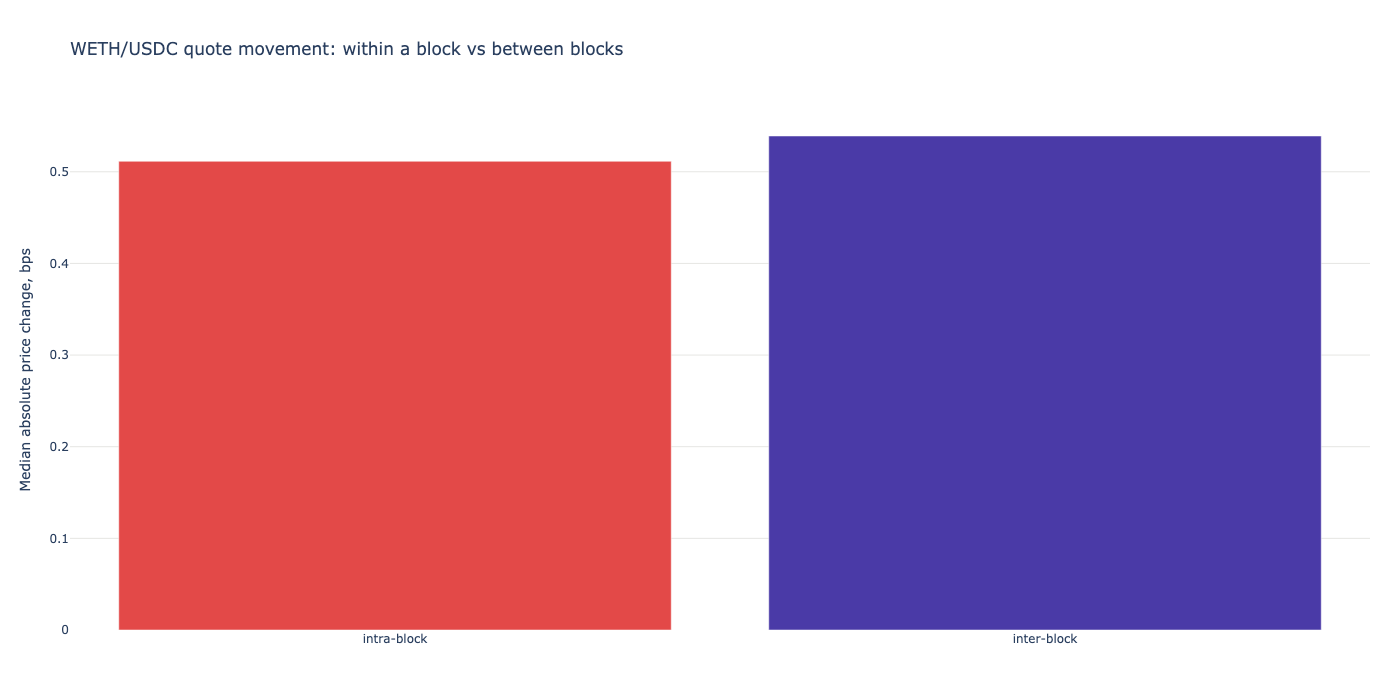

,median |Δ| bps,std bps,samples
"intra-block (end of block b → end of block b+1, trade blocks)",0.51,17.91,"74,513.00"
inter-block (consecutive block ends),0.54,124.73,"13,522.00"


In [8]:
probe = con.execute("""
    WITH p AS (
        SELECT q.quote_block, q.kind,
               (q.quoted_amount_out / 1e6) / (q.quoted_amount_in / 1e18) AS px
        FROM quotes q
        JOIN trades t ON t.tx_hash = q.tx_hash AND t.log_index = q.log_index
        WHERE q.size = 'probe' AND q.success AND t.venue = 'tessera' AND t.block_number >= ?
          AND t.token_in = ? AND t.token_out = ?
    )
    SELECT quote_block, kind, any_value(px) AS px FROM p GROUP BY 1, 2
""", [WINDOW_START_BLOCK, WETH, USDC]).df()

probe = probe[np.isfinite(probe["px"]) & (probe["px"] > 0)]
end_of_block = probe[probe["kind"] == "prev"].set_index("quote_block")["px"].sort_index()          # price at end of block b
# The 'same' quote for a trade at block b+1 is the end of block b+1; pair with 'prev' (end of block b) for the same trade block
same = probe[probe["kind"] == "same"].set_index("quote_block")["px"]
prev_for_same = end_of_block.reindex(same.index - 1)
intra = ((same.values / prev_for_same.values) - 1) * 1e4
consecutive = end_of_block[end_of_block.index.diff().fillna(0) == 1]
inter = (consecutive.values / end_of_block.shift(1).reindex(consecutive.index).values - 1) * 1e4
intra = pd.Series(intra).replace([np.inf, -np.inf], np.nan).dropna(); inter = pd.Series(inter).replace([np.inf, -np.inf], np.nan).dropna()

stats = pd.DataFrame({
    "intra-block (end of block b → end of block b+1, trade blocks)": [intra.abs().median(), intra.std(), len(intra)],
    "inter-block (consecutive block ends)": [inter.abs().median(), inter.std(), len(inter)],
}, index=["median |Δ| bps", "std bps", "samples"]).T

fig = go.Figure()
fig.add_bar(x=["intra-block", "inter-block"], y=[intra.abs().median(), inter.abs().median()], name="median |Δ|", marker_color=[COLOURS["fill"], COLOURS["quote"]])
style(fig, "WETH/USDC quote movement: within a block vs between blocks", "", "Median absolute price change, bps", legend=False).show()
display(stats.style.format("{:,.2f}"))

## Spread over time

- Using both probe directions at the same block end we can reconstruct Tessera's quoted bid, ask and spread for WETH/USDC
- 0x described sudden spread widenings unrelated to volatility; here is the hourly median and 90th percentile of the quoted spread

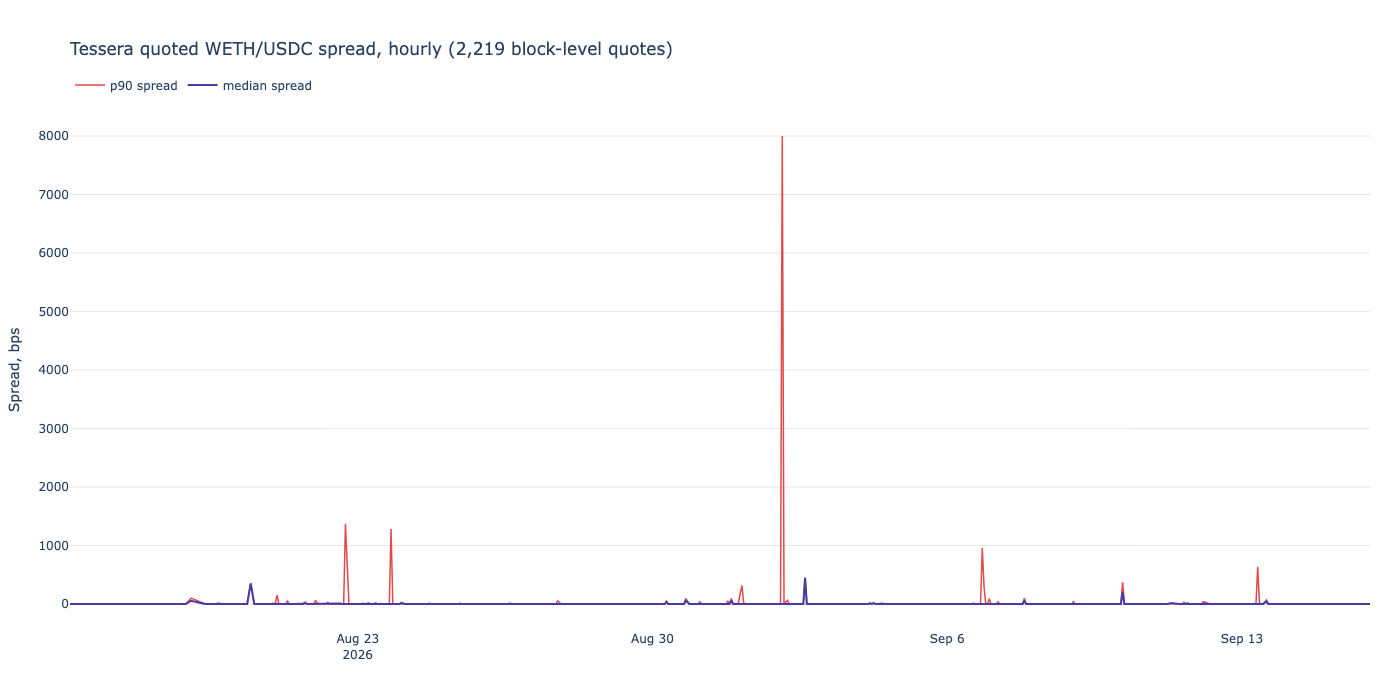

,count,mean,std,min,10%,50%,90%,99%,max
spread bps,"2,219.00",17.08,435.29,0.24,0.26,0.87,1.96,77.09,"20,000.00"


In [9]:
spread = con.execute("""
    WITH p AS (
        SELECT q.quote_block, t.token_in,
               CASE WHEN t.token_in = ? THEN (q.quoted_amount_out / 1e6) / (q.quoted_amount_in / 1e18)
                    ELSE (q.quoted_amount_in / 1e6) / (q.quoted_amount_out / 1e18) END AS px,
               any_value(b.timestamp) AS ts
        FROM quotes q
        JOIN trades t ON t.tx_hash = q.tx_hash AND t.log_index = q.log_index
        JOIN blocks b ON b.block_number = q.quote_block
        WHERE q.size = 'probe' AND q.success AND q.kind = 'prev' AND t.venue = 'tessera' AND t.block_number >= ?
          AND ((t.token_in = ? AND t.token_out = ?) OR (t.token_in = ? AND t.token_out = ?))
        GROUP BY 1, 2, 3
    )
    SELECT quote_block, any_value(ts) AS ts,
           max(CASE WHEN token_in = ? THEN px END) AS bid,
           max(CASE WHEN token_in = ? THEN px END) AS ask
    FROM p GROUP BY 1 HAVING bid IS NOT NULL AND ask IS NOT NULL
""", [WETH, WINDOW_START_BLOCK, WETH, USDC, USDC, WETH, WETH, USDC]).df()
spread["spread_bps"] = (spread["ask"] - spread["bid"]) / ((spread["ask"] + spread["bid"]) / 2) * 1e4
spread["hour"] = spread["ts"].dt.floor("h")
hourly = spread.groupby("hour")["spread_bps"].agg(median="median", p90=lambda s: s.quantile(0.9), n="size")

fig = go.Figure()
fig.add_scatter(x=hourly.index, y=hourly["p90"], mode="lines", name="p90 spread", line=dict(color=COLOURS["fill"], width=1.5))
fig.add_scatter(x=hourly.index, y=hourly["median"], mode="lines", name="median spread", line=dict(color=COLOURS["quote"], width=2))
style(fig, f"Tessera quoted WETH/USDC spread, hourly ({len(spread):,} block-level quotes)", "", "Spread, bps").show()
display(spread["spread_bps"].describe(percentiles=[0.1, 0.5, 0.9, 0.99]).to_frame("spread bps").T.style.format("{:,.2f}"))

# Question 2: who pays?

## Degradation by aggregator

- The same venue, the same blocks, but very different outcomes depending on which aggregator routed the trade
- KyberSwap and 0x flow gets fills close to the quote; OKX, 1inch, Paraswap, LI.FI and Binance Wallet flow pays the full skim
- 0x publicly monitors fill quality and cuts sources that misbehave; the numbers suggest that pressure works

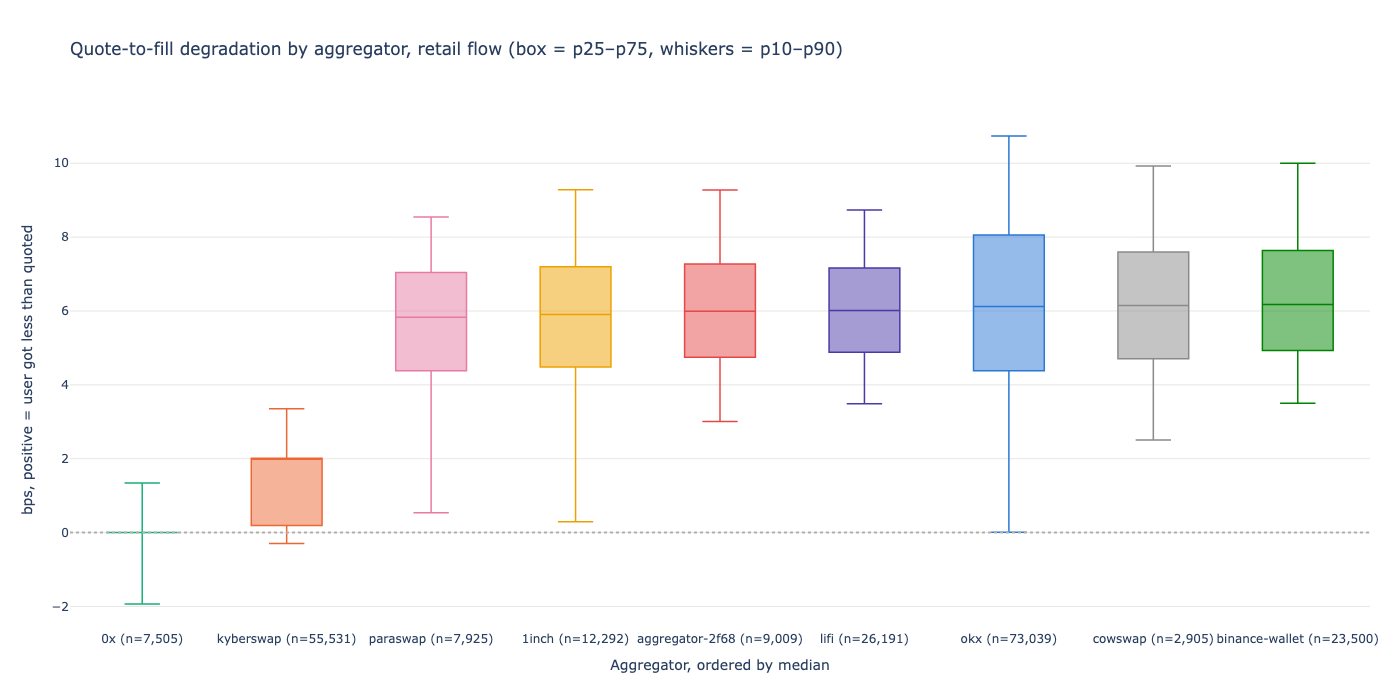

,n,p10,p50,p90,mean
aggregator,,,,,
0x,"7,505",-1.93,0.00,1.34,-0.18
kyberswap,"55,531",-0.30,2.00,3.35,1.93
paraswap,"7,925",0.54,5.83,8.55,5.55
1inch,"12,292",0.29,5.91,9.29,5.90
aggregator-2f68,"9,009",3.01,5.99,9.27,5.87
lifi,"26,191",3.49,6.01,8.73,6.55
okx,"73,039",0.01,6.12,10.74,6.69
cowswap,"2,905",2.51,6.15,9.93,6.15
binance-wallet,"23,500",3.50,6.17,10.00,6.27


In [10]:
agg = df[df["flow"] == "retail"].groupby("aggregator")["quote_to_fill_bps"].agg(
    n="size", p10=lambda s: s.quantile(0.1), p25=lambda s: s.quantile(0.25), p50="median", p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.9), mean="mean"
)
agg = agg[agg["n"] >= 500].sort_values("p50")

fig = go.Figure()
for name, row in agg.iterrows():
    label = f"{name} (n={int(row['n']):,})"
    fig.add_box(
        name=label, x=[label],
        q1=[row["p25"]], median=[row["p50"]], q3=[row["p75"]], lowerfence=[row["p10"]], upperfence=[row["p90"]],
        marker_color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"), line_width=1.5,
    )
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Quote-to-fill degradation by aggregator, retail flow (box = p25–p75, whiskers = p10–p90)", "Aggregator, ordered by median", "bps, positive = user got less than quoted", legend=False).show()
display(agg[["n", "p10", "p50", "p90", "mean"]].style.format({"n": "{:,}", "p10": "{:.2f}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}"}))

## Degradation by front-end

- Aggregator routers often carry a front-end identifier: KyberSwap's `clientData` names the integrating app, ERC-4337 flow identifies smart-wallet users (Coinbase Smart Wallet)
- This puts retail-facing brand names on the numbers

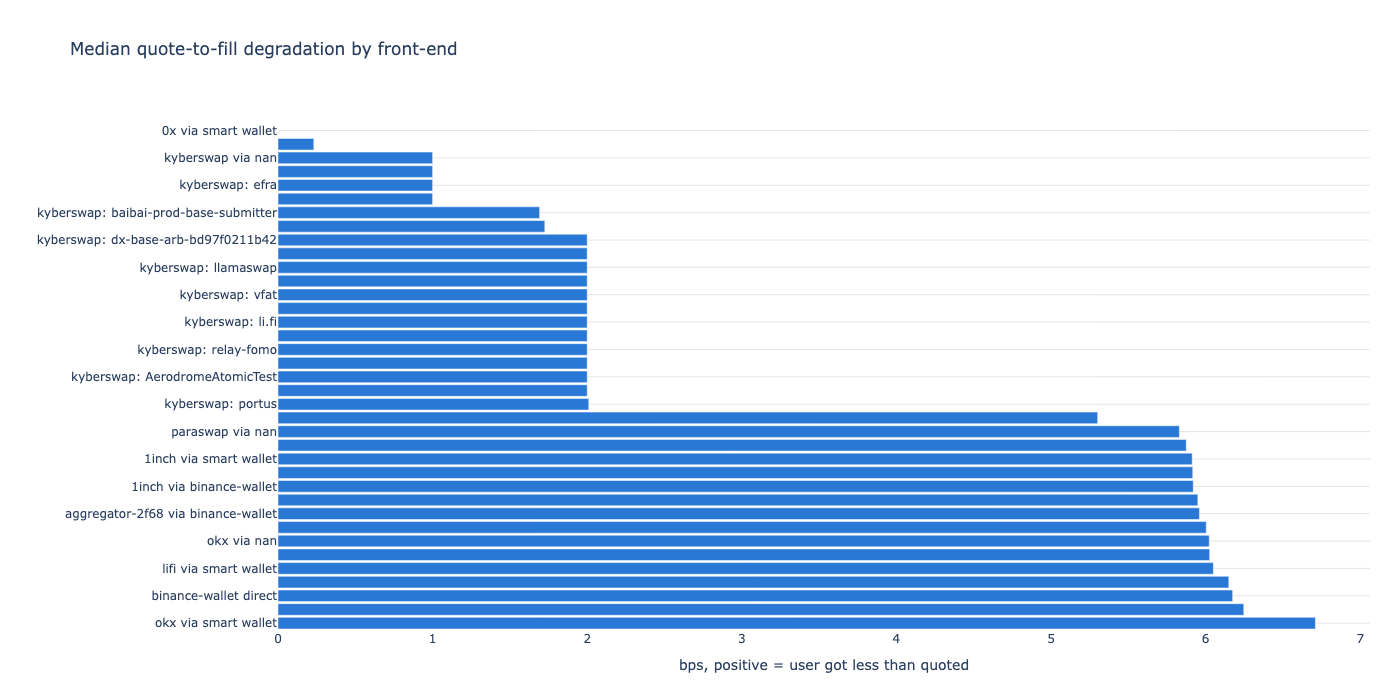

,n,p50,p90,notional_usd
frontend_label,,,,
okx via smart wallet,"6,055",6.71,14.61,"$779,456"
okx via relay,"16,102",6.25,10.33,"$4,201,885"
binance-wallet direct,"23,500",6.17,10.00,"$11,140,770"
cowswap direct,"2,905",6.15,9.93,"$1,843,667"
lifi via smart wallet,"15,467",6.05,8.53,"$3,530,290"
aggregator-2f68 via nan,"4,428",6.03,9.54,"$2,453,940"
okx via nan,"50,363",6.02,10.59,"$12,567,624"
1inch via lifi,734,6.00,8.28,"$531,269"
aggregator-2f68 via binance-wallet,"4,436",5.96,8.84,"$1,445,420"


In [11]:
import json

def frontend_label(row):
    if isinstance(row["client_data"], str) and row["client_data"].startswith("{"):
        try:
            return f"{row['aggregator']}: {json.loads(row['client_data']).get('Source', '?')}"
        except json.JSONDecodeError:
            pass
    if row["wallet_kind"] == "erc4337":
        return f"{row['aggregator']} via smart wallet"
    if row["frontend"] and row["frontend"] != row["aggregator"]:
        return f"{row['aggregator']} via {row['frontend']}"
    return f"{row['aggregator']} direct"

retail = df[df["flow"] == "retail"].copy()
retail["frontend_label"] = retail.apply(frontend_label, axis=1)
fe = retail.groupby("frontend_label").agg(n=("tx_hash", "size"), p50=("quote_to_fill_bps", "median"), p90=("quote_to_fill_bps", lambda s: s.quantile(0.9)), notional_usd=("notional_usd", "sum"))
fe = fe[fe["n"] >= 300].sort_values("p50", ascending=False)

fig = go.Figure(go.Bar(x=fe["p50"], y=fe.index, orientation="h", marker_color=COLOURS["retail"], name="median"))
style(fig, "Median quote-to-fill degradation by front-end", "bps, positive = user got less than quoted", "", legend=False)
fig.update_layout(height=max(500, 34 * len(fe)))
fig.show()
display(fe.style.format({"n": "{:,}", "p50": "{:.2f}", "p90": "{:.2f}", "notional_usd": "${:,.0f}"}))

## What the user allowed vs what was taken

- From the aggregator router calldata we decoded the minimum output each user accepted; relative to Tessera's quote this is their slippage tolerance in bps
- Retail tolerances are typically 50 to 200 bps, twenty to thirty times the median skim, so the fill never reverts and nothing looks wrong to the user
- Only trades where the router order maps onto this single Tessera leg are shown (multi-hop routes express the bound in a different token)

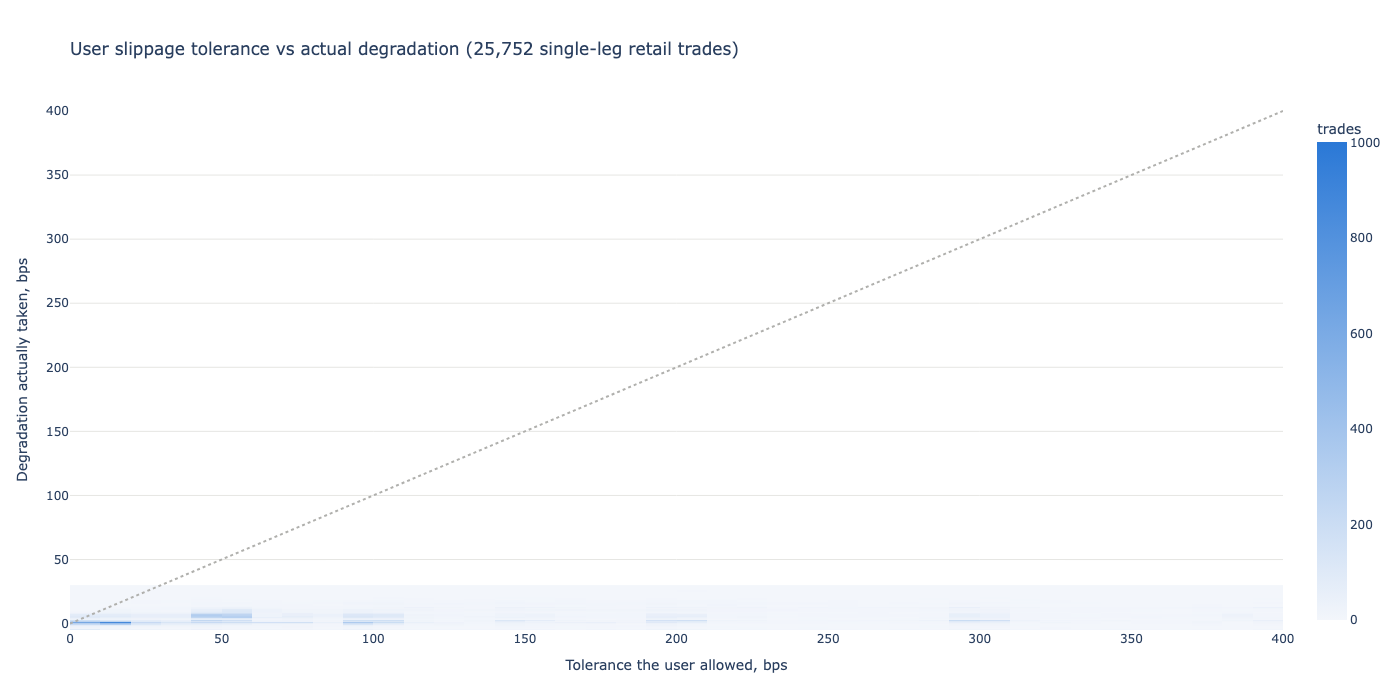

Median tolerance 100 bps, median degradation 2.0 bps, median share of tolerance consumed 1.8%, fills within 1 bps of the user's bound: 1.10%


,count,50%,90%
aggregator,,,
kyberswap,"10,291",100,414
okx,"5,572",114,457
0x,"4,249",569,602
paraswap,"1,965",49,200
1inch,"1,929",196,658
aggregator-2f68,"1,746",50,100


In [12]:
bound = df[(df["flow"] == "retail") & df["order_matches_leg"].fillna(False) & df["user_slippage_bps"].between(0, 1000)]

fig = go.Figure(go.Histogram2d(
    x=bound["user_slippage_bps"], y=bound["quote_to_fill_bps"].clip(-5, 30),
    xbins=dict(start=0, end=400, size=10), ybins=dict(start=-5, end=30, size=1),
    colorscale=[[0, "#f3f6fb"], [1, COLOURS["retail"]]], showscale=True, colorbar=dict(title="trades"),
))
fig.add_shape(type="line", x0=0, y0=0, x1=400, y1=400, line=dict(color="#b0b0ad", dash="dot"))
style(fig, f"User slippage tolerance vs actual degradation ({len(bound):,} single-leg retail trades)", "Tolerance the user allowed, bps", "Degradation actually taken, bps", legend=False)
fig.update_xaxes(range=[0, 400])
fig.show()

consumed = bound["user_slippage_consumed_fraction"].clip(-0.5, 1.5)
at_bound = (bound["user_headroom_bps"] < 1).mean()
print(f"Median tolerance {bound['user_slippage_bps'].median():.0f} bps, median degradation {bound['quote_to_fill_bps'].median():.1f} bps, "
      f"median share of tolerance consumed {consumed.median():.1%}, fills within 1 bps of the user's bound: {at_bound:.2%}")
display(bound.groupby("aggregator")["user_slippage_bps"].describe(percentiles=[0.5, 0.9])[["count", "50%", "90%"]].sort_values("count", ascending=False).style.format("{:,.0f}"))

## Degradation by trade size

- Is the skim a flat fee-like amount or does it scale with size like adverse selection would?
- Median and 90th percentile quote-to-fill bps by USD notional bucket, retail flow on pairs with a USDC leg

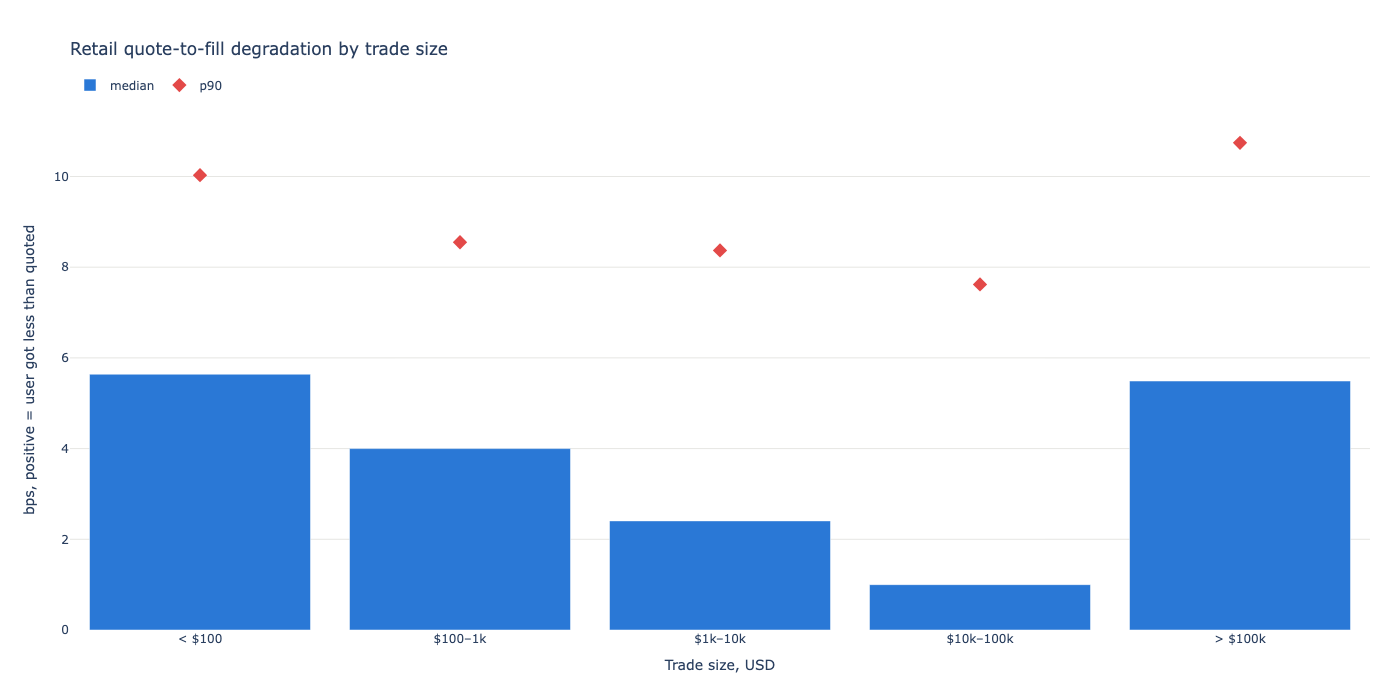

,n,p50,p90,mean,notional_usd,extracted_usd
size_bucket,,,,,,
< $100,"126,397",5.64,10.03,5.92,"$3,522,316","$1,695"
$100–1k,"67,875",4.00,8.55,3.99,"$23,760,401","$9,324"
$1k–10k,"21,043",2.41,8.37,3.51,"$60,650,906","$19,469"
$10k–100k,"2,480",1.00,7.62,2.66,"$52,711,921","$16,561"
> $100k,85,5.49,10.74,5.23,"$13,600,585","$7,253"


In [13]:
bins = [0, 100, 1_000, 10_000, 100_000, np.inf]
labels = ["< $100", "$100–1k", "$1k–10k", "$10k–100k", "> $100k"]
retail = df[(df["flow"] == "retail") & df["notional_usd"].notna()].copy()
retail["size_bucket"] = pd.cut(retail["notional_usd"], bins=bins, labels=labels)
size = retail.groupby("size_bucket", observed=True)["quote_to_fill_bps"].agg(n="size", p50="median", p90=lambda s: s.quantile(0.9), mean="mean")
size["notional_usd"] = retail.groupby("size_bucket", observed=True)["notional_usd"].sum()
size["extracted_usd"] = retail.groupby("size_bucket", observed=True)["extracted_usd"].sum()

fig = go.Figure()
fig.add_bar(x=size.index.astype(str), y=size["p50"], name="median", marker_color=COLOURS["retail"])
fig.add_scatter(x=size.index.astype(str), y=size["p90"], mode="markers", name="p90", marker=dict(color=COLOURS["fill"], size=11, symbol="diamond"))
style(fig, "Retail quote-to-fill degradation by trade size", "Trade size, USD", "bps, positive = user got less than quoted").show()
display(size.style.format({"n": "{:,}", "p50": "{:.2f}", "p90": "{:.2f}", "mean": "{:.2f}", "notional_usd": "${:,.0f}", "extracted_usd": "${:,.0f}"}))

# Question 3: how much?

## Against a fair price: was routing to Tessera worth it?

- Aggregators route to Tessera because its quote beats the AMM pools. We check that claim against the marginal price of the deepest pool for each pair at the same moment (end of the previous block)
- `quote vs fair` is the price improvement the aggregator saw; `fill vs fair` is what the user actually got
- Only WETH/USDC and cbBTC/USDC have a reference that is both deep and fresh (reference age ≤ 3 blocks); thin pairs are excluded because their pool price is stale and wide

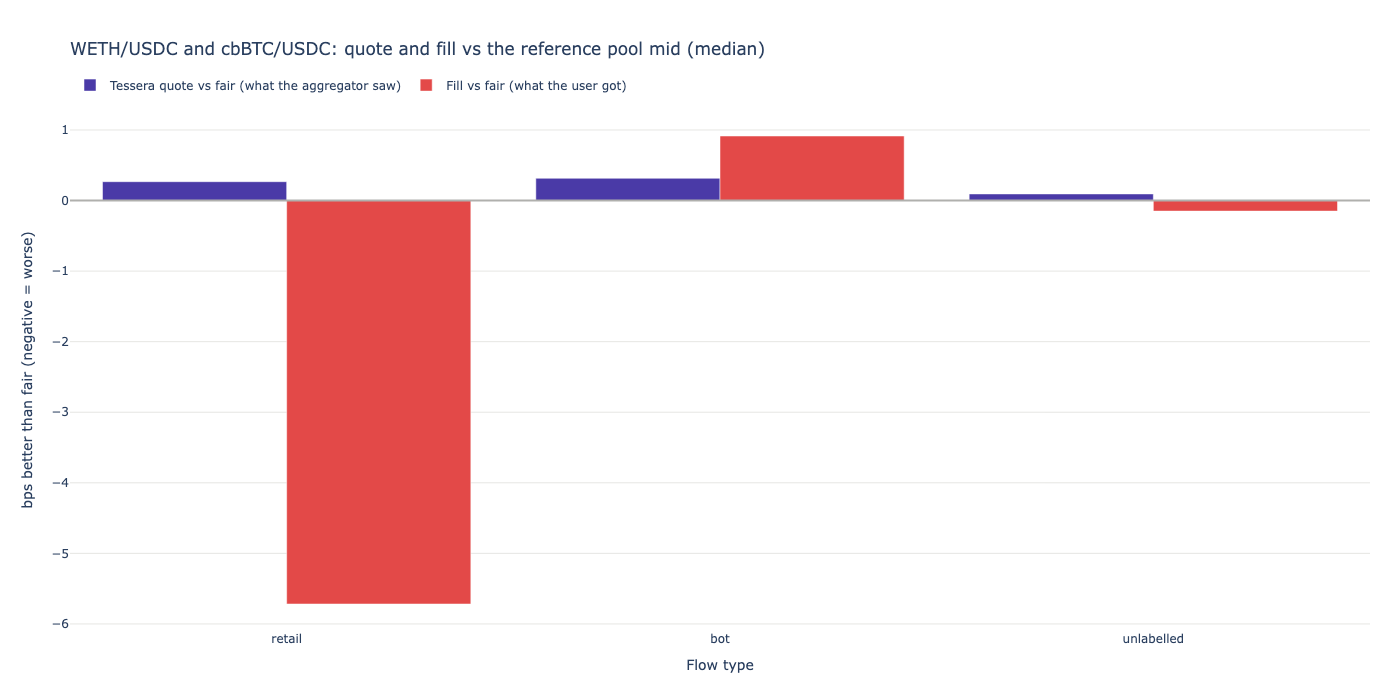

,n,quote_vs_fair_p50,fill_vs_fair_p50,fill_vs_fair_mean,pool_fee_bps
flow,,,,,
retail,"56,437",0.27,5.72,6.16,1.0
bot,"29,718",0.31,-0.91,-0.73,1.0
unlabelled,"82,187",0.09,0.15,1.88,1.0


fill_vs_fair is positive when the user received less than the reference mid implied. A direct pool fill would have cost roughly the pool fee plus impact.


In [14]:
majors = df[df["pair"].isin(["WETH/USDC", "USDC/WETH", "cbBTC/USDC", "USDC/cbBTC"]) & (df["benchmark_age_blocks"] <= 3)]
fair = majors.groupby("flow").agg(
    n=("tx_hash", "size"),
    quote_vs_fair_p50=("quote_vs_benchmark_bps", "median"),
    fill_vs_fair_p50=("fill_vs_benchmark_bps", "median"),
    fill_vs_fair_mean=("fill_vs_benchmark_bps", "mean"),
    pool_fee_bps=("benchmark_fee_bps", "median"),
).reindex(FLOW_ORDER)

fig = go.Figure()
fig.add_bar(name="Tessera quote vs fair (what the aggregator saw)", x=FLOW_ORDER, y=fair["quote_vs_fair_p50"], marker_color=COLOURS["quote"])
fig.add_bar(name="Fill vs fair (what the user got)", x=FLOW_ORDER, y=-fair["fill_vs_fair_p50"], marker_color=COLOURS["fill"])
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
fig.update_layout(barmode="group")
style(fig, "WETH/USDC and cbBTC/USDC: quote and fill vs the reference pool mid (median)", "Flow type", "bps better than fair (negative = worse)").show()
display(fair.style.format({"n": "{:,}", "quote_vs_fair_p50": "{:.2f}", "fill_vs_fair_p50": "{:.2f}", "fill_vs_fair_mean": "{:.2f}", "pool_fee_bps": "{:.1f}"}))
print("fill_vs_fair is positive when the user received less than the reference mid implied. A direct pool fill would have cost roughly the pool fee plus impact.")

## Fill vs fair price, distribution

- The full distribution for the majors: bots sit slightly better than the fair mid, retail sits several basis points below it
- The gap between the two curves is the value transferred from retail users, in the same blocks, at the same venue

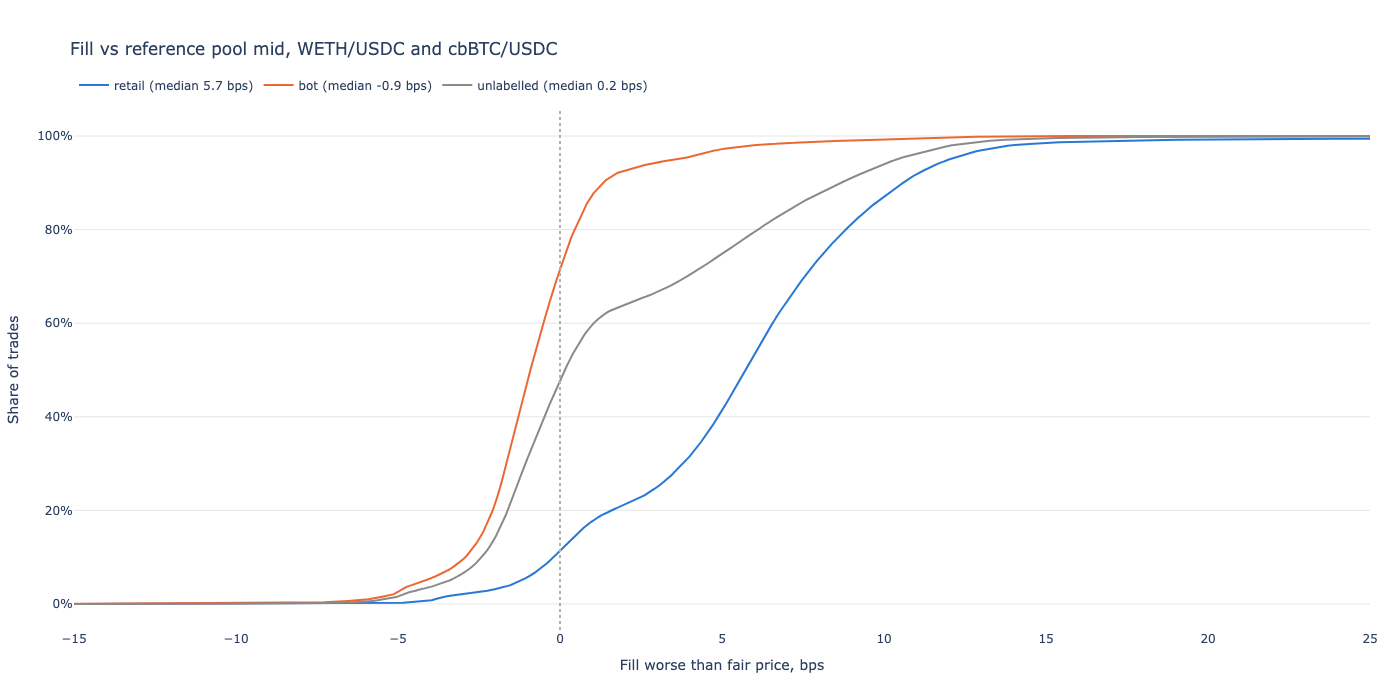

In [15]:
fig = go.Figure()
for flow in FLOW_ORDER:
    s = majors.loc[majors["flow"] == flow, "fill_vs_benchmark_bps"].dropna().clip(-15, 25).sort_values()
    fig.add_scatter(x=s.values, y=np.linspace(0, 1, len(s)), mode="lines", name=f"{flow} (median {s.median():.1f} bps)", line=dict(color=COLOURS[flow], width=2))
fig.add_vline(x=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Fill vs reference pool mid, WETH/USDC and cbBTC/USDC", "Fill worse than fair price, bps", "Share of trades")
fig.update_yaxes(tickformat=".0%")
fig.show()

## Dollars extracted from retail

- Quote-to-fill gap in USD, summed per day and split by aggregator, for retail trades with a USDC leg
- Negative days would mean users got more than quoted; there are none

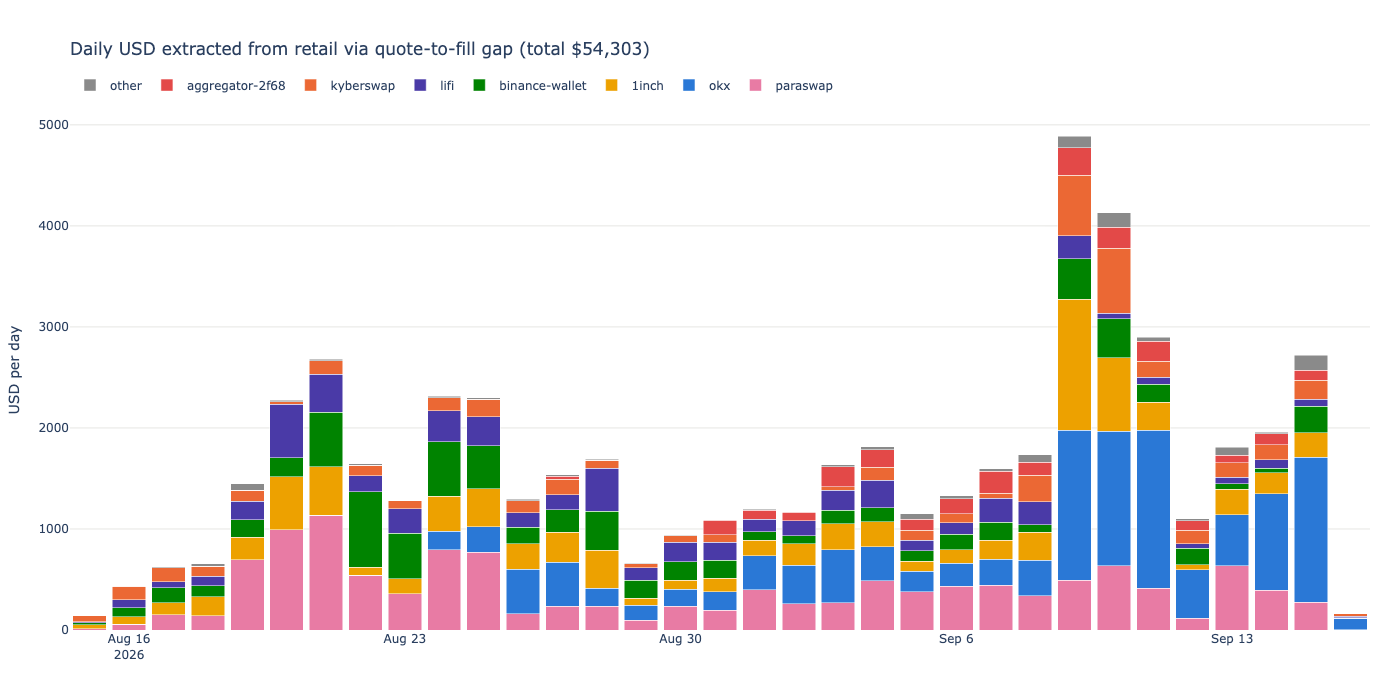

,trades,notional_usd,extracted_usd,extracted_bps_of_volume
aggregator,,,,
paraswap,"7,925","$22,432,694","$12,789",5.70
okx,"73,038","$17,881,553","$12,475",6.98
1inch,"12,270","$15,667,091","$8,443",5.39
binance-wallet,"23,499","$11,140,162","$7,185",6.45
lifi,"26,190","$9,969,498","$5,641",5.66
kyberswap,"55,529","$65,830,558","$4,345",0.66
aggregator-2f68,"9,009","$3,999,111","$2,392",5.98
cowswap,"2,905","$1,843,667","$1,075",5.83
0x,"7,505","$5,455,590",$-43,-0.08


In [16]:
retail = df[(df["flow"] == "retail") & df["extracted_usd"].notna()]
daily = retail.pivot_table(index="day", columns="aggregator", values="extracted_usd", aggfunc="sum", fill_value=0)
top_aggs = daily.sum().sort_values(ascending=False).index[:7]
daily["other"] = daily.drop(columns=top_aggs).sum(axis=1)
daily = daily[list(top_aggs) + ["other"]]

fig = go.Figure()
for name in daily.columns:
    fig.add_bar(name=name, x=daily.index, y=daily[name], marker_color=AGGREGATOR_COLOURS.get(name, "#8a8a8a"))
fig.update_layout(barmode="stack")
style(fig, f"Daily USD extracted from retail via quote-to-fill gap (total ${retail['extracted_usd'].sum():,.0f})", "", "USD per day").show()

total_by_agg = retail.groupby("aggregator").agg(trades=("tx_hash", "size"), notional_usd=("notional_usd", "sum"), extracted_usd=("extracted_usd", "sum"))
total_by_agg["extracted_bps_of_volume"] = total_by_agg["extracted_usd"] / total_by_agg["notional_usd"] * 1e4
display(total_by_agg.sort_values("extracted_usd", ascending=False).style.format({"trades": "{:,}", "notional_usd": "${:,.0f}", "extracted_usd": "${:,.0f}", "extracted_bps_of_volume": "{:.2f}"}))

## Extrapolation over the full history

- The quote enrichment covers the analysis window; raw trade volume is available for the whole ten months
- We apply the window's per-pair retail median degradation and the window's retail share of volume to the monthly full-history volume
- This is an estimate: it assumes the skim rate and the retail share were stable over time

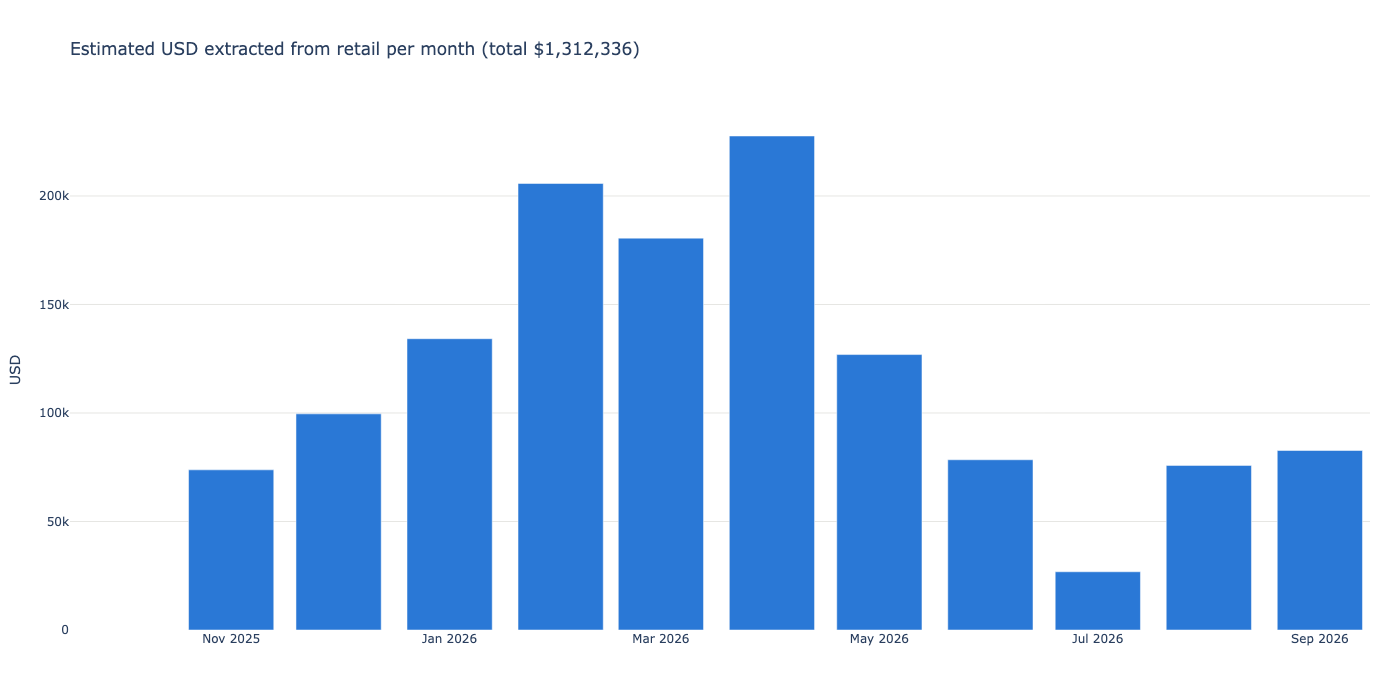

,volume_usd,estimated_extracted_usd,trades
month,,,
2025-10-01 00:00:00,$7,$0,4
2025-11-01 00:00:00,"$368,356,687","$73,797","525,677"
2025-12-01 00:00:00,"$481,557,744","$99,597","704,404"
2026-01-01 00:00:00,"$659,905,803","$134,219","1,036,259"
2026-02-01 00:00:00,"$1,019,423,126","$205,761","1,126,428"
2026-03-01 00:00:00,"$926,658,710","$180,572","808,886"
2026-04-01 00:00:00,"$1,198,228,735","$227,640","546,909"
2026-05-01 00:00:00,"$659,903,789","$126,920","699,255"
2026-06-01 00:00:00,"$457,428,911","$78,439","272,596"


In [17]:
monthly = con.execute("""
    SELECT date_trunc('month', t.timestamp) AS month, t.symbol_in || '/' || t.symbol_out AS pair,
           sum(CASE WHEN t.token_in = ? THEN t.amount_in_decimal WHEN t.token_out = ? THEN t.amount_out_decimal END) AS volume_usd,
           count(*) AS trades
    FROM trade_analysis t
    WHERE t.venue = 'tessera'
    GROUP BY 1, 2
""", [USDC, USDC]).df().dropna(subset=["volume_usd"])

window_pairs = df[df["notional_usd"].notna()].groupby("pair").agg(
    retail_share=("flow", lambda s: (s == "retail").mean()),
    retail_median_bps=("quote_to_fill_bps", lambda s: s[df.loc[s.index, "flow"] == "retail"].median()),
)
monthly = monthly.join(window_pairs, on="pair").dropna()
monthly["estimated_extracted_usd"] = monthly["volume_usd"] * monthly["retail_share"] * monthly["retail_median_bps"] / 1e4
est = monthly.groupby("month").agg(volume_usd=("volume_usd", "sum"), estimated_extracted_usd=("estimated_extracted_usd", "sum"), trades=("trades", "sum"))

fig = go.Figure(go.Bar(x=est.index, y=est["estimated_extracted_usd"], marker_color=COLOURS["retail"], name="estimated USD extracted"))
style(fig, f"Estimated USD extracted from retail per month (total ${est['estimated_extracted_usd'].sum():,.0f})", "", "USD", legend=False).show()
display(est.style.format({"volume_usd": "${:,.0f}", "estimated_extracted_usd": "${:,.0f}", "trades": "{:,}"}))

# Why are retail fills worse?

## Who trades when: fills and price updates inside the block

- Overlay where in the block the keeper updates prices, where bots fill, and where retail fills
- Bots trade at the very top of the block (ahead of the first keeper update) or at the very bottom (after the refresh); almost never in between
- Retail transactions arrive through aggregator routers and ordinary mempool ordering and land in the middle of the block, after the top-of-block update

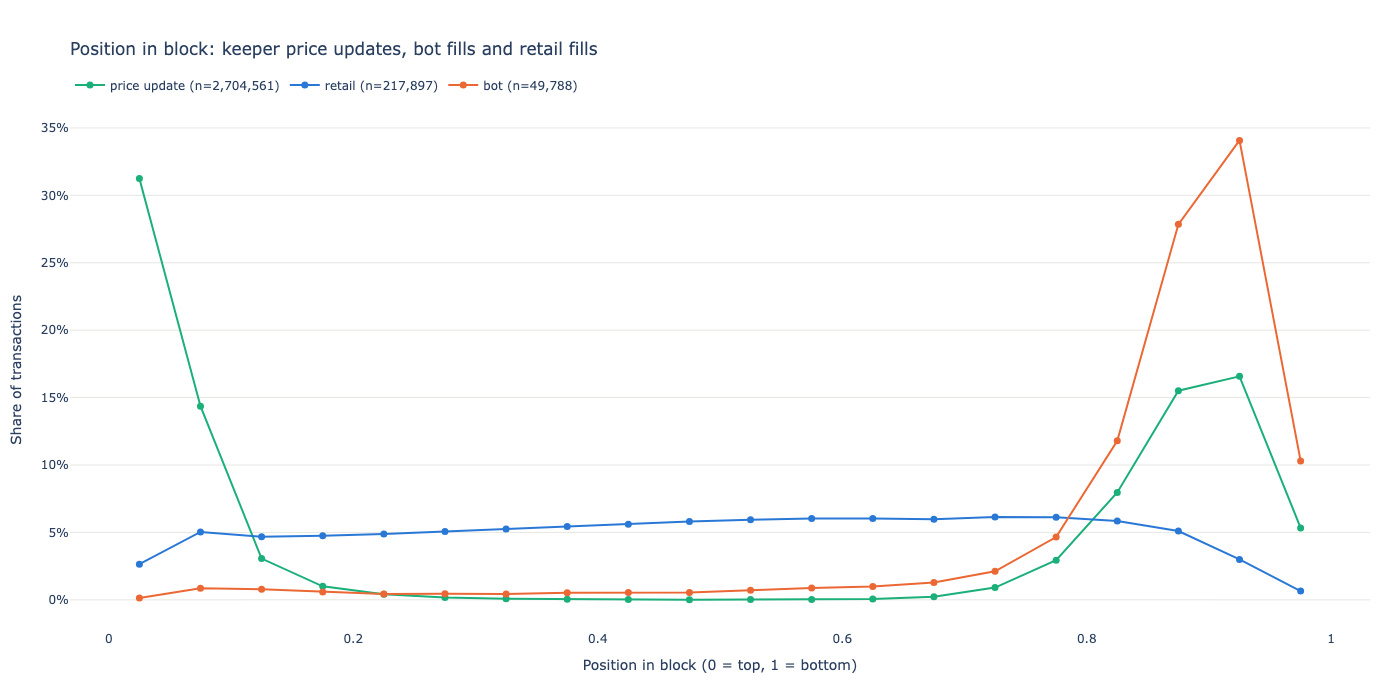

In [18]:
edges = np.linspace(0, 1, 21)
centers = (edges[:-1] + edges[1:]) / 2
upd = con.execute("""
    SELECT rel_gas_position FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND rel_gas_position IS NOT NULL
""", [WINDOW_START_BLOCK]).df()["rel_gas_position"]

fig = go.Figure()
series = {"price update": upd, "retail": df.loc[df["flow"] == "retail", "rel_gas_position"], "bot": df.loc[df["flow"] == "bot", "rel_gas_position"]}
for name, s in series.items():
    hist, _ = np.histogram(s.dropna().clip(0, 0.999), bins=edges)
    fig.add_scatter(x=centers, y=hist / hist.sum(), mode="lines+markers", name=f"{name} (n={len(s):,})", line=dict(color=COLOURS[name], width=2), marker=dict(size=7))
style(fig, "Position in block: keeper price updates, bot fills and retail fills", "Position in block (0 = top, 1 = bottom)", "Share of transactions")
fig.update_yaxes(tickformat=".0%")
fig.show()

## Degradation by position in block

- If the top-of-block reprice is the mechanism, fills that land after it should be worse than fills that land before it or after the end-of-block refresh
- Median quote-to-fill by in-block position, retail vs bot
- The venue does not discriminate by counterparty: bots that do land mid-block pay the same five bps as retail. The price is worse for everyone in the middle of every block; bots simply avoid the middle and retail cannot

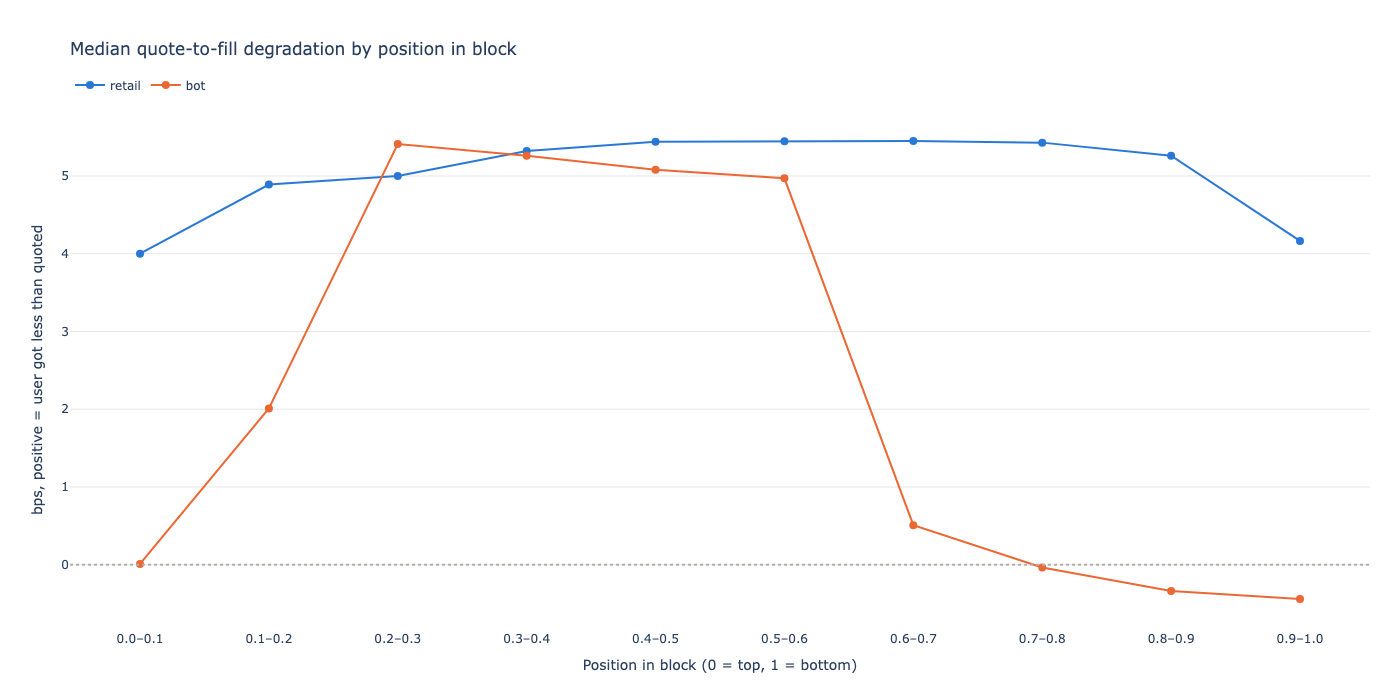

flow,bot,retail,unlabelled
position_bin,,,
0.0–0.1,0.01,4.00,0.01
0.1–0.2,2.01,4.89,4.81
0.2–0.3,5.41,5.00,5.46
0.3–0.4,5.26,5.32,5.60
0.4–0.5,5.08,5.44,5.59
0.5–0.6,4.97,5.45,5.49
0.6–0.7,0.51,5.45,5.51
0.7–0.8,-0.04,5.43,4.79
0.8–0.9,-0.34,5.26,-0.14


In [19]:
df["position_bin"] = pd.cut(df["rel_gas_position"], bins=np.linspace(0, 1, 11), labels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], include_lowest=True)
pos = df.groupby(["position_bin", "flow"], observed=True)["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()

fig = go.Figure()
for flow in ["retail", "bot"]:
    sub = pos[(pos["flow"] == flow) & (pos["n"] >= 200)]
    fig.add_scatter(x=sub["position_bin"].astype(str), y=sub["p50"], mode="lines+markers", name=flow, line=dict(color=COLOURS[flow], width=2), marker=dict(size=8))
fig.add_hline(y=0, line=dict(color="#b0b0ad", dash="dot"))
style(fig, "Median quote-to-fill degradation by position in block", "Position in block (0 = top, 1 = bottom)", "bps, positive = user got less than quoted").show()
display(pos.pivot(index="position_bin", columns="flow", values="p50").style.format("{:.2f}"))

## Did a price update land before the fill in the same block?

- For every trade, count the keeper price updates earlier in the same block
- Trades that settle after a reprice in their own block should be worse than trades that settle before any update
- The pattern is exact: zero updates before the fill gives zero degradation, one update (the top-of-block reprice) gives the full skim, two updates (the refresh has landed) gives zero again

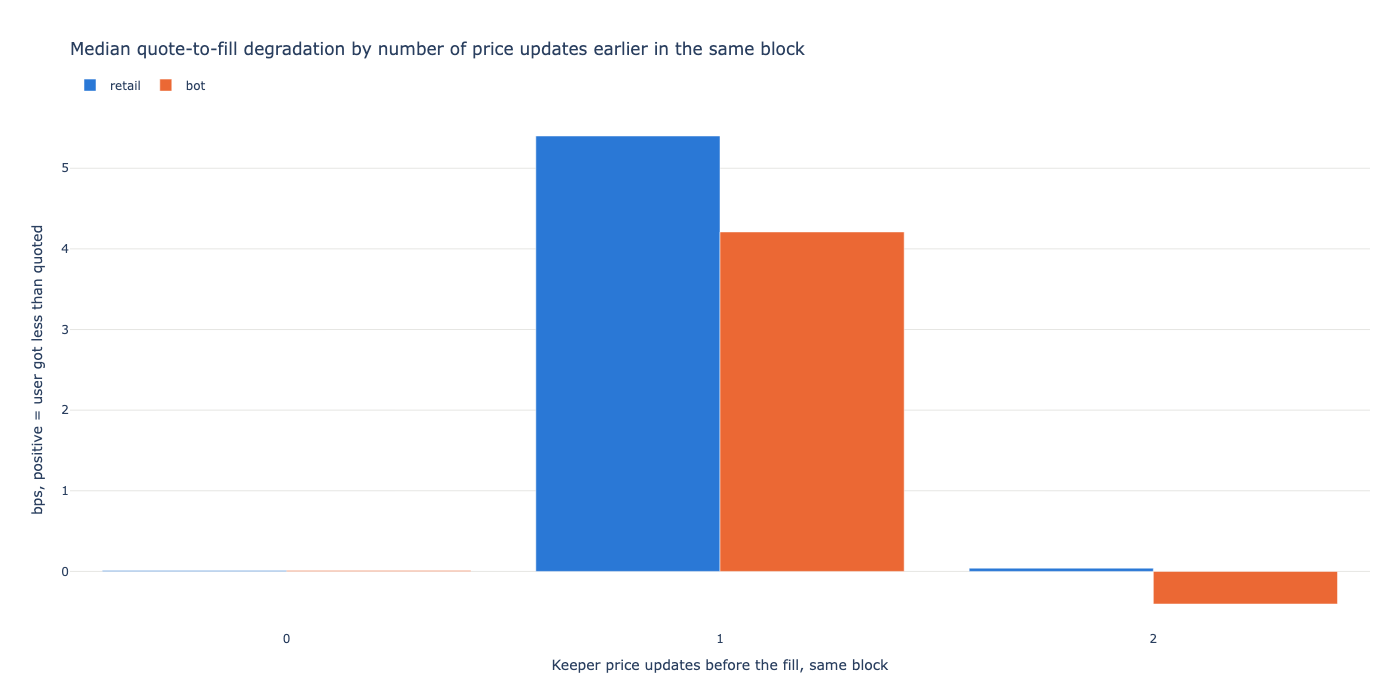

In [20]:
before = con.execute("""
    SELECT t.tx_hash, t.log_index,
           count(u.tx_index) FILTER (WHERE u.tx_index < t.tx_index) AS updates_before,
           count(u.tx_index) FILTER (WHERE u.tx_index > t.tx_index) AS updates_after
    FROM trades t
    LEFT JOIN price_updates u ON u.block_number = t.block_number AND u.selector = '0x1667d875'
    WHERE t.venue = 'tessera' AND t.block_number >= ?
    GROUP BY 1, 2
""", [WINDOW_START_BLOCK]).df()
df = df.drop(columns=[c for c in ["updates_before", "updates_after"] if c in df.columns]).merge(before, on=["tx_hash", "log_index"], how="left")
df["updates_before_bucket"] = pd.cut(df["updates_before"], bins=[-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"])

ub = df.groupby(["updates_before_bucket", "flow"], observed=True)["quote_to_fill_bps"].agg(n="size", p50="median").reset_index()
fig = go.Figure()
for flow in ["retail", "bot"]:
    sub = ub[(ub["flow"] == flow) & (ub["n"] >= 200)]
    fig.add_bar(x=sub["updates_before_bucket"].astype(str), y=sub["p50"], name=flow, marker_color=COLOURS[flow])
fig.update_layout(barmode="group")
style(fig, "Median quote-to-fill degradation by number of price updates earlier in the same block", "Keeper price updates before the fill, same block", "bps, positive = user got less than quoted").show()
display(ub.pivot(index="updates_before_bucket", columns="flow", values=["n", "p50"]).style.format("{:,.2f}"))

## Was the worse price permanent or temporary?

- Compare each fill with the quote at the end of the previous block (before) and the quote at the end of its own block (after)
- If the fill is worse than *both*, the price was widened around the fill and tightened again afterwards: the temporary widening 0x described
- If the fill is only worse than the earlier quote, the market moved and the new price stayed
- Roughly three quarters of retail fills are worse than both quotes: the worse price is a transient state of the venue, not a market move

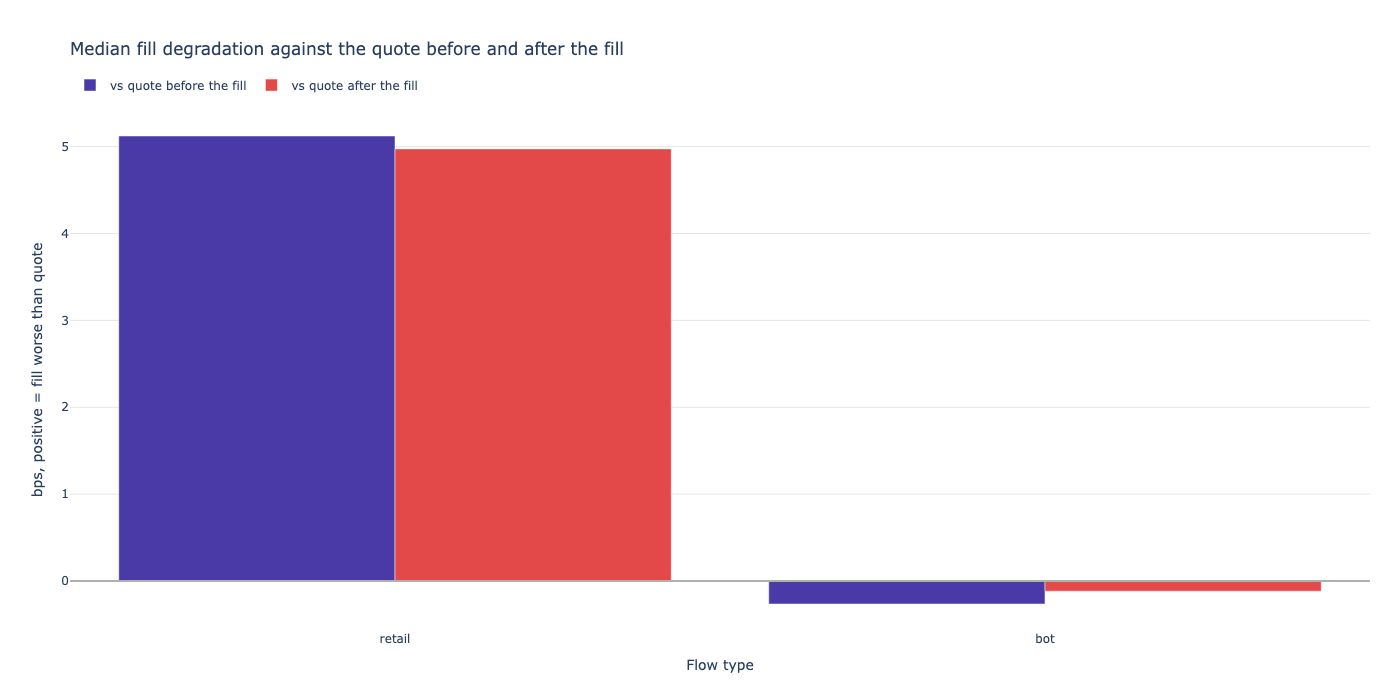

Retail fills worse than both the earlier and the later quote by more than 1 bps: 73%; worse only than the earlier quote: 9%


In [21]:
retail = df[df["flow"] == "retail"].dropna(subset=["quote_to_fill_bps", "same_block_quote_to_fill_bps"])
worse_than_both = ((retail["quote_to_fill_bps"] > 1) & (retail["same_block_quote_to_fill_bps"] > 1)).mean()
worse_only_before = ((retail["quote_to_fill_bps"] > 1) & (retail["same_block_quote_to_fill_bps"] <= 1)).mean()

comp = pd.DataFrame({
    "vs quote before (end of previous block)": [df.loc[df["flow"] == f, "quote_to_fill_bps"].median() for f in ["retail", "bot"]],
    "vs quote after (end of own block)": [df.loc[df["flow"] == f, "same_block_quote_to_fill_bps"].median() for f in ["retail", "bot"]],
}, index=["retail", "bot"])

fig = go.Figure()
fig.add_bar(name="vs quote before the fill", x=comp.index, y=comp.iloc[:, 0], marker_color=COLOURS["quote"])
fig.add_bar(name="vs quote after the fill", x=comp.index, y=comp.iloc[:, 1], marker_color=COLOURS["fill"])
fig.update_layout(barmode="group")
fig.add_hline(y=0, line=dict(color="#b0b0ad"))
style(fig, "Median fill degradation against the quote before and after the fill", "Flow type", "bps, positive = fill worse than quote").show()
print(f"Retail fills worse than both the earlier and the later quote by more than 1 bps: {worse_than_both:.0%}; worse only than the earlier quote: {worse_only_before:.0%}")

## What changes in the price update payload?

- The keeper payload is three packed 32-bit words that we could not fully decode without the engine source
- The first word is, however, revealing: the top-of-block update sets it to a baseline plus an offset, the end-of-block update resets it to the baseline
- Whatever the parameter is, the venue is in one state while retail settles and in another when the aggregator quotes and bots trade

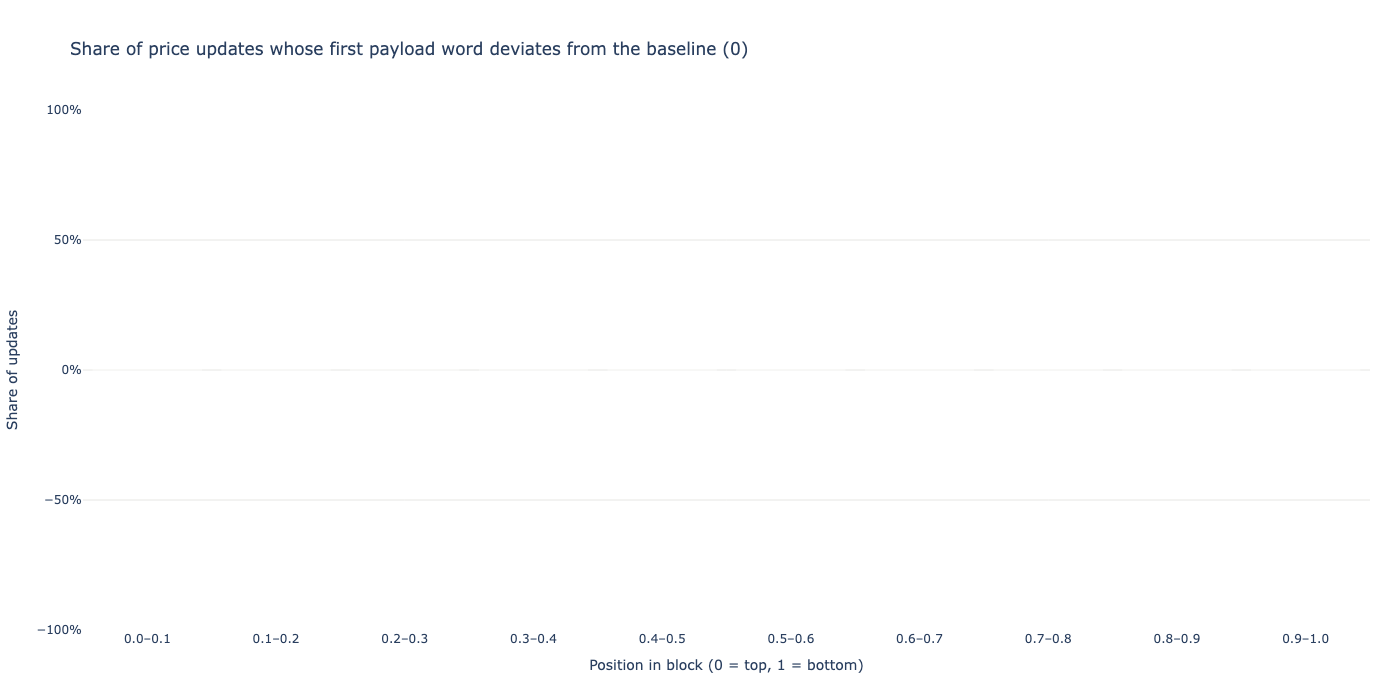

,n,share_nonzero,median_abs_offset
position_bin,,,
0.0–0.1,"1,233,796",0.0%,0
0.1–0.2,"109,756",0.0%,0
0.2–0.3,"16,104",0.0%,0
0.3–0.4,"3,056",0.0%,0
0.4–0.5,"1,058",0.0%,0
0.5–0.6,"1,119",0.0%,0
0.6–0.7,"7,916",0.0%,0
0.7–0.8,"104,212",0.0%,0
0.8–0.9,"634,996",0.0%,0


In [22]:
words = con.execute("""
    SELECT rel_gas_position, ('0x' || substr(input, 11, 8))::UBIGINT AS word1
    FROM price_update_analysis
    WHERE selector = '0x1667d875' AND block_number >= ? AND length(input) >= 74 AND rel_gas_position IS NOT NULL
""", [WINDOW_START_BLOCK]).df()
baseline = words["word1"].mode().iloc[0]
words["offset"] = words["word1"].astype("int64") - int(baseline)
words["position_bin"] = pd.cut(words["rel_gas_position"], bins=np.linspace(0, 1, 11), labels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], include_lowest=True)
w = words.groupby("position_bin", observed=True)["offset"].agg(n="size", share_nonzero=lambda s: (s != 0).mean(), median_abs_offset=lambda s: s.abs().median())

fig = go.Figure(go.Bar(x=w.index.astype(str), y=w["share_nonzero"], marker_color=COLOURS["price update"], name="share of updates with offset ≠ 0"))
style(fig, f"Share of price updates whose first payload word deviates from the baseline ({baseline})", "Position in block (0 = top, 1 = bottom)", "Share of updates", legend=False)
fig.update_yaxes(tickformat=".0%")
fig.show()
display(w.style.format({"n": "{:,}", "share_nonzero": "{:.1%}", "median_abs_offset": "{:,.0f}"}))

## Summary

- Headline numbers for the analysis window

In [23]:
retail = df[df["flow"] == "retail"]
bots = df[df["flow"] == "bot"]
majors_retail = majors[majors["flow"] == "retail"]
majors_bot = majors[majors["flow"] == "bot"]
best = agg["p50"].idxmin(); worst = agg["p50"].idxmax()

headline = pd.DataFrame([
    ("Analysis window", f"{df['timestamp'].min():%Y-%m-%d} – {df['timestamp'].max():%Y-%m-%d}"),
    ("Tessera trades in window", f"{len(df):,} (retail {len(retail):,}, bot {len(bots):,}, unlabelled {(df['flow'] == 'unlabelled').sum():,})"),
    ("Retail volume with USDC leg", f"${retail['notional_usd'].sum():,.0f}"),
    ("Median retail fill vs Tessera's own quote", f"{retail['quote_to_fill_bps'].median():.2f} bps worse"),
    ("Median bot fill vs Tessera's own quote", f"{bots['quote_to_fill_bps'].median():.2f} bps"),
    ("Median retail fill vs fair pool price (majors)", f"{majors_retail['fill_vs_benchmark_bps'].median():.2f} bps worse"),
    ("Median bot fill vs fair pool price (majors)", f"{majors_bot['fill_vs_benchmark_bps'].median():.2f} bps"),
    ("Tessera quote vs fair pool price (majors, retail)", f"{majors_retail['quote_vs_benchmark_bps'].median():.2f} bps better"),
    ("Best aggregator for the user", f"{best} ({agg.loc[best, 'p50']:.2f} bps)"),
    ("Worst aggregator for the user", f"{worst} ({agg.loc[worst, 'p50']:.2f} bps)"),
    ("Median user slippage tolerance (single-leg orders)", f"{bound['user_slippage_bps'].median():.0f} bps"),
    ("USD extracted from retail in window (quote-to-fill)", f"${retail['extracted_usd'].sum():,.0f}"),
    ("Estimated USD extracted over full history", f"${est['estimated_extracted_usd'].sum():,.0f}"),
    ("Keeper updates in first 10% / last 20% of block", f"{top:.0%} / {bottom:.0%}"),
], columns=["Metric", "Value"])
display(headline.style.hide(axis="index"))

Metric,Value
Analysis window,2026-08-15 – 2026-09-16
Tessera trades in window,"466,950 (retail 217,897, bot 49,788, unlabelled 199,265)"
Retail volume with USDC leg,"$154,246,129"
Median retail fill vs Tessera's own quote,5.12 bps worse
Median bot fill vs Tessera's own quote,-0.26 bps
Median retail fill vs fair pool price (majors),5.72 bps worse
Median bot fill vs fair pool price (majors),-0.91 bps
"Tessera quote vs fair pool price (majors, retail)",0.27 bps better
Best aggregator for the user,0x (0.00 bps)
Worst aggregator for the user,binance-wallet (6.17 bps)
